## 1. Setup & Data Loading

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

In [43]:
# Plotting Configuration
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (15, 6)
sns.set_style("whitegrid")

In [44]:
# Load Data
print("Loading data...")
train = pd.read_csv('train.csv')
print(f"Train shape: {train.shape}")

Loading data...
Train shape: (9048, 98)


### Data Splitting
To ensure a robust analysis and avoid look-ahead bias, we split the provided `train.csv` into a training set and a hold-out test set. 
The last **180 days** are reserved as the test set for final validation.

In [ ]:
# Split Train/Test (Last 180 days as Test)
cutoff_date_id = train['date_id'].max() - 179  # Inclusive of the last 180 days
train_df = train[train['date_id'] < cutoff_date_id]
test_df = train[train['date_id'] >= cutoff_date_id]

print(f'Train Data Shape: {train_df.shape}')
print(f'Test Data Shape: {test_df.shape} (Last 180 days)')
print(f'Train Date Range: {train_df.date_id.min()} to {train_df.date_id.max()}')
print(f'Test Date Range: {test_df.date_id.min()} to {test_df.date_id.max()}')

# Use train_df for subsequent EDA to avoid leakage
train = train_df # Overwrite 'train' to ensure downstream cells use the training split

### Data Description

**train.csv**: Historic market data. The coverage stretches back decades; expect to see extensive missing values early on.

*   **date_id**: An identifier for a single trading day.
*   **M***: Market Dynamics/Technical features.
*   **E***: Macro Economic features.
*   **I***: Interest Rate features.
*   **P***: Price/Valuation features.
*   **V***: Volatility features.
*   **S***: Sentiment features.
*   **MOM***: Momentum features.
*   **D***: Dummy/Binary features.
*   **forward_returns**: The returns from buying the S&P 500 and selling it a day later. Train set only.
*   **risk_free_rate**: The federal funds rate. Train set only.
*   **market_forward_excess_returns**: Forward returns relative to expectations. Computed by subtracting the rolling five-year mean forward returns and winsorizing the result using a median absolute deviation (MAD) with a criterion of 4. Train set only.


In [45]:
# Basic Overview
print("Train Info:")
display(train.info())
print("\nTrain Head:")
display(train.head())

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9048 entries, 0 to 9047
Data columns (total 98 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date_id                        9048 non-null   int64  
 1   D1                             9048 non-null   int64  
 2   D2                             9048 non-null   int64  
 3   D3                             9048 non-null   int64  
 4   D4                             9048 non-null   int64  
 5   D5                             9048 non-null   int64  
 6   D6                             9048 non-null   int64  
 7   D7                             9048 non-null   int64  
 8   D8                             9048 non-null   int64  
 9   D9                             9048 non-null   int64  
 10  E1                             7264 non-null   float64
 11  E10                            8042 non-null   float64
 12  E11                            8042 

None


Train Head:


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


## 2. Missing Value Analysis

In [46]:
# Calculate Missing Statistics
missing_stats = pd.DataFrame({
    'feature': train.columns,
    'missing_count': train.isnull().sum(),
    'total_count': len(train),
    'missing_pct': train.isnull().sum() / len(train) * 100,
    'dtype': train.dtypes
})

missing_stats = missing_stats[missing_stats['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Total features with missing values: {len(missing_stats)}")
print(f"Overall missing rate: {train.isnull().sum().sum() / (train.shape[0] * train.shape[1]) * 100:.2f}%")

# Categories for missing rates
low_missing = missing_stats[missing_stats['missing_pct'] < 5]
medium_missing = missing_stats[(missing_stats['missing_pct'] >= 5) & (missing_stats['missing_pct'] < 30)]
high_missing = missing_stats[missing_stats['missing_pct'] >= 30]
very_high_missing = missing_stats[missing_stats['missing_pct'] >= 50]

print(f"Low missing (<5%): {len(low_missing)}")
print(f"Medium missing (5-30%): {len(medium_missing)}")
print(f"High missing (30-50%): {len(high_missing) - len(very_high_missing)}")
print(f"Very High missing (>=50%): {len(very_high_missing)}")

Total features with missing values: 85
Overall missing rate: 15.53%
Low missing (<5%): 0
Medium missing (5-30%): 73
High missing (30-50%): 4
Very High missing (>=50%): 8


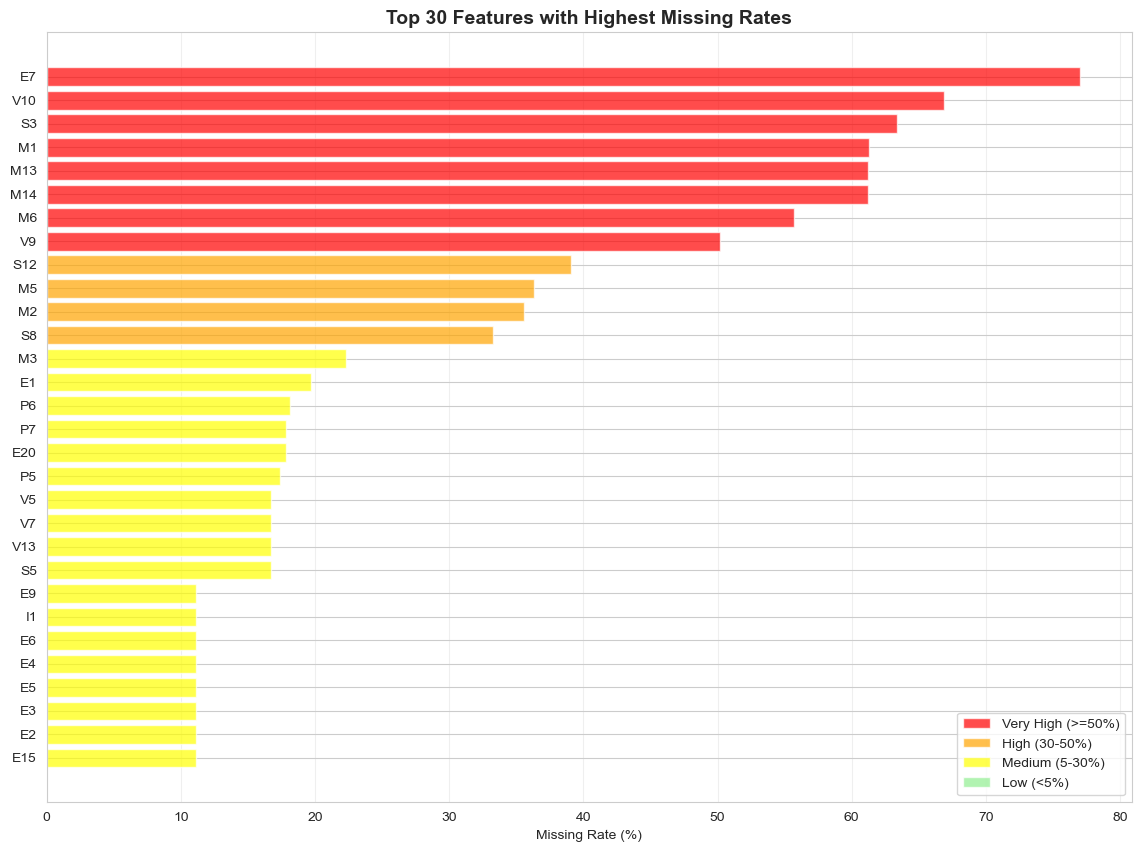

In [47]:
# Visual: Top 30 Features with Highest Missing Rates
plt.figure(figsize=(14, 10))
missing_stats_plot = missing_stats.head(30)
colors = ['red' if x >= 50 else 'orange' if x >= 30 else 'yellow' if x >= 5 else 'lightgreen' 
          for x in missing_stats_plot['missing_pct']]

plt.barh(range(len(missing_stats_plot)), missing_stats_plot['missing_pct'], color=colors, alpha=0.7)
plt.yticks(range(len(missing_stats_plot)), missing_stats_plot['feature'])
plt.xlabel('Missing Rate (%)')
plt.title('Top 30 Features with Highest Missing Rates', fontsize=14, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.gca().invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Very High (>=50%)'),
    Patch(facecolor='orange', alpha=0.7, label='High (30-50%)'),
    Patch(facecolor='yellow', alpha=0.7, label='Medium (5-30%)'),
    Patch(facecolor='lightgreen', alpha=0.7, label='Low (<5%)')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.show()

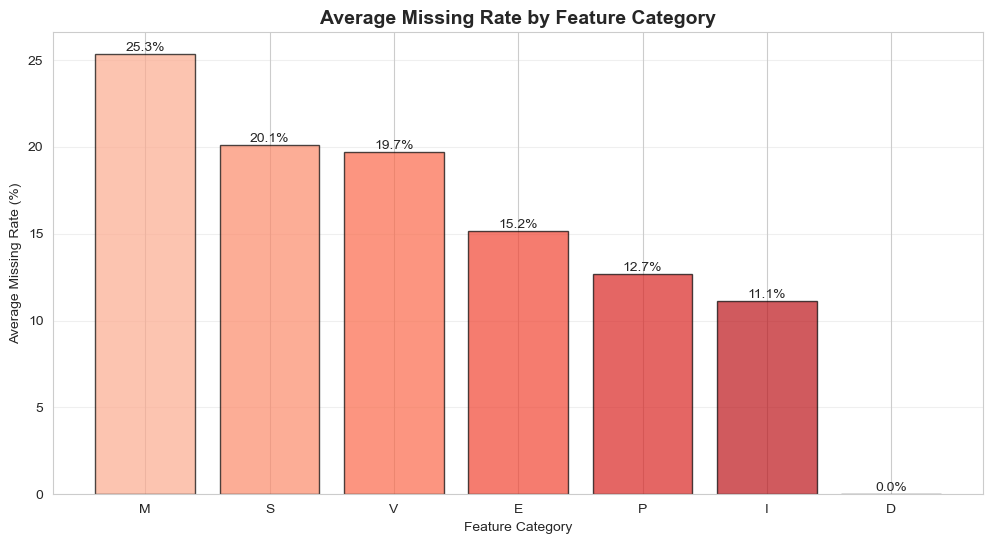

In [48]:
# Calculate missing stats by category
feature_categories = {
    'D': [col for col in train.columns if col.startswith('D')],
    'E': [col for col in train.columns if col.startswith('E')],
    'I': [col for col in train.columns if col.startswith('I')],
    'M': [col for col in train.columns if col.startswith('M')],
    'P': [col for col in train.columns if col.startswith('P')],
    'S': [col for col in train.columns if col.startswith('S')],
    'V': [col for col in train.columns if col.startswith('V')],
}

category_stats = []
for cat_name, cat_features in feature_categories.items():
    cat_df = train[cat_features]
    total_values = cat_df.shape[0] * cat_df.shape[1]
    missing_values = cat_df.isnull().sum().sum()
    missing_pct = missing_values / total_values * 100 if total_values > 0 else 0
    category_stats.append({'category': cat_name, 'missing_pct': missing_pct, 'count': len(cat_features)})

category_df = pd.DataFrame(category_stats).sort_values('missing_pct', ascending=False)

# Visual: Missing Rates by Category
plt.figure(figsize=(12, 6))
colors_cat = plt.cm.get_cmap('Reds')(np.linspace(0.3, 0.9, len(category_df)))
bars = plt.bar(category_df['category'], category_df['missing_pct'], color=colors_cat, alpha=0.7, edgecolor='black')

plt.xlabel('Feature Category')
plt.ylabel('Average Missing Rate (%)')
plt.title('Average Missing Rate by Feature Category', fontsize=14, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')
plt.show()

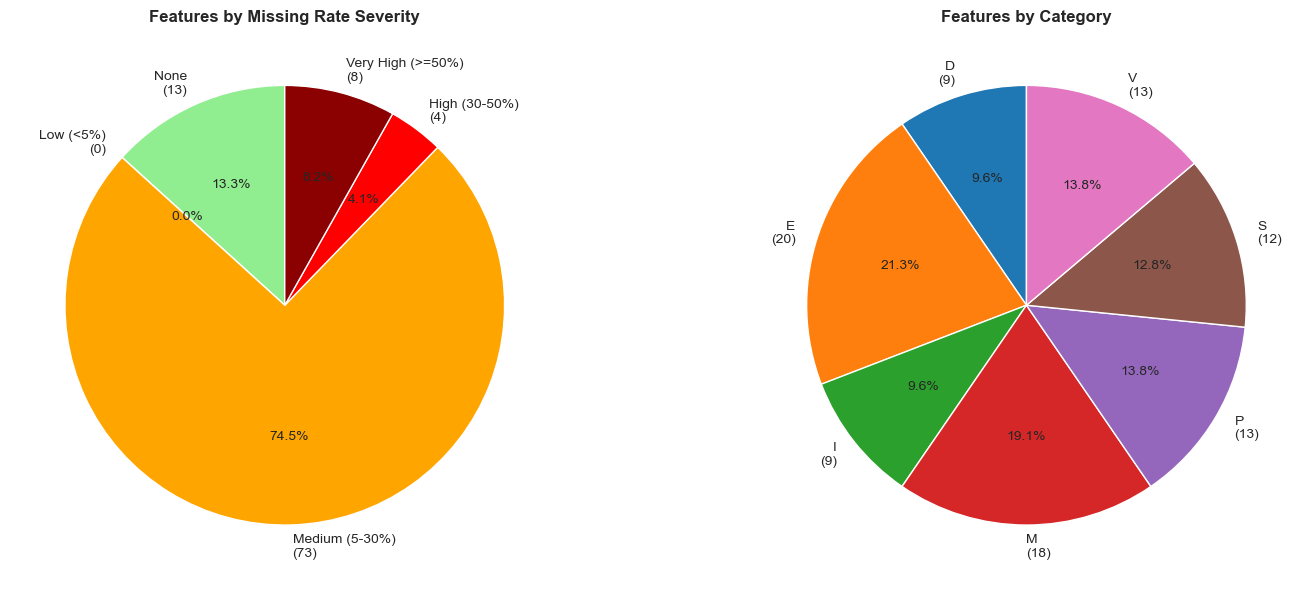

In [49]:
# Visual: Missing Value Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: By Severity
sizes = [
    train.shape[1] - len(missing_stats),
    len(low_missing),
    len(medium_missing),
    len(high_missing) - len(very_high_missing),
    len(very_high_missing)
]
labels = [
    f'None\n({sizes[0]})',
    f'Low (<5%)\n({sizes[1]})',
    f'Medium (5-30%)\n({sizes[2]})',
    f'High (30-50%)\n({sizes[3]})',
    f'Very High (>=50%)\n({sizes[4]})'
]
colors_pie = ['lightgreen', 'yellow', 'orange', 'red', 'darkred']
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Features by Missing Rate Severity', fontweight='bold')

# Right: By Category
category_counts = [len(feats) for feats in feature_categories.values()]
category_labels = [f'{cat}\n({count})' for cat, count in zip(feature_categories.keys(), category_counts)]
axes[1].pie(category_counts, labels=category_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Features by Category', fontweight='bold')

plt.tight_layout()
plt.show()

In [50]:
# Calculate Daily Missing Rates
# Overall
daily_missing = train.isnull().mean(axis=1) * 100
daily_df = pd.DataFrame({'date_id': train['date_id'], 'missing_pct': daily_missing})

# Per Category
for cat_name, cat_feats in feature_categories.items():
    daily_df[f'missing_{cat_name}'] = train[cat_feats].isnull().mean(axis=1) * 100

print("Daily missing rate calculation complete.")
display(daily_df.head())

Daily missing rate calculation complete.


,date_id,missing_pct,missing_D,missing_E,missing_I,missing_M,missing_P,missing_S,missing_V
0,0,86.734694,0.0,100.0,100.0,100.0,100.0,100.0,100.0
1,1,86.734694,0.0,100.0,100.0,100.0,100.0,100.0,100.0
2,2,86.734694,0.0,100.0,100.0,100.0,100.0,100.0,100.0
3,3,86.734694,0.0,100.0,100.0,100.0,100.0,100.0,100.0
4,4,86.734694,0.0,100.0,100.0,100.0,100.0,100.0,100.0


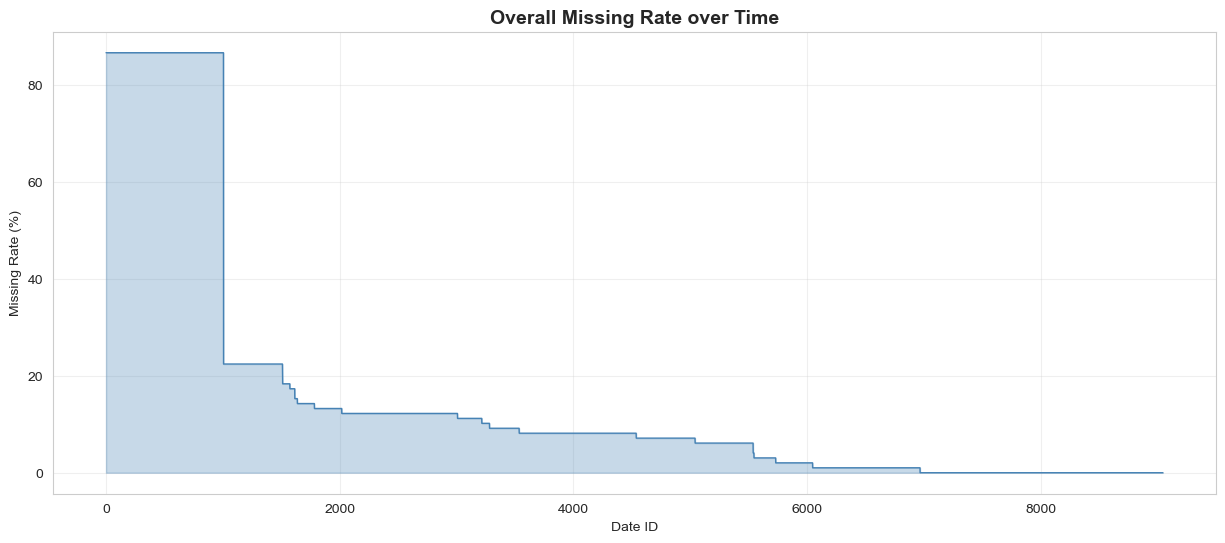

In [51]:
# Visual: Overall Daily Missing Rate over Time
plt.figure(figsize=(15, 6))
plt.plot(daily_df['date_id'], daily_df['missing_pct'], linewidth=1, color='steelblue')
plt.title('Overall Missing Rate over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date ID')
plt.ylabel('Missing Rate (%)')
plt.grid(True, alpha=0.3)
plt.fill_between(daily_df['date_id'], daily_df['missing_pct'], alpha=0.3, color='steelblue')
plt.show()

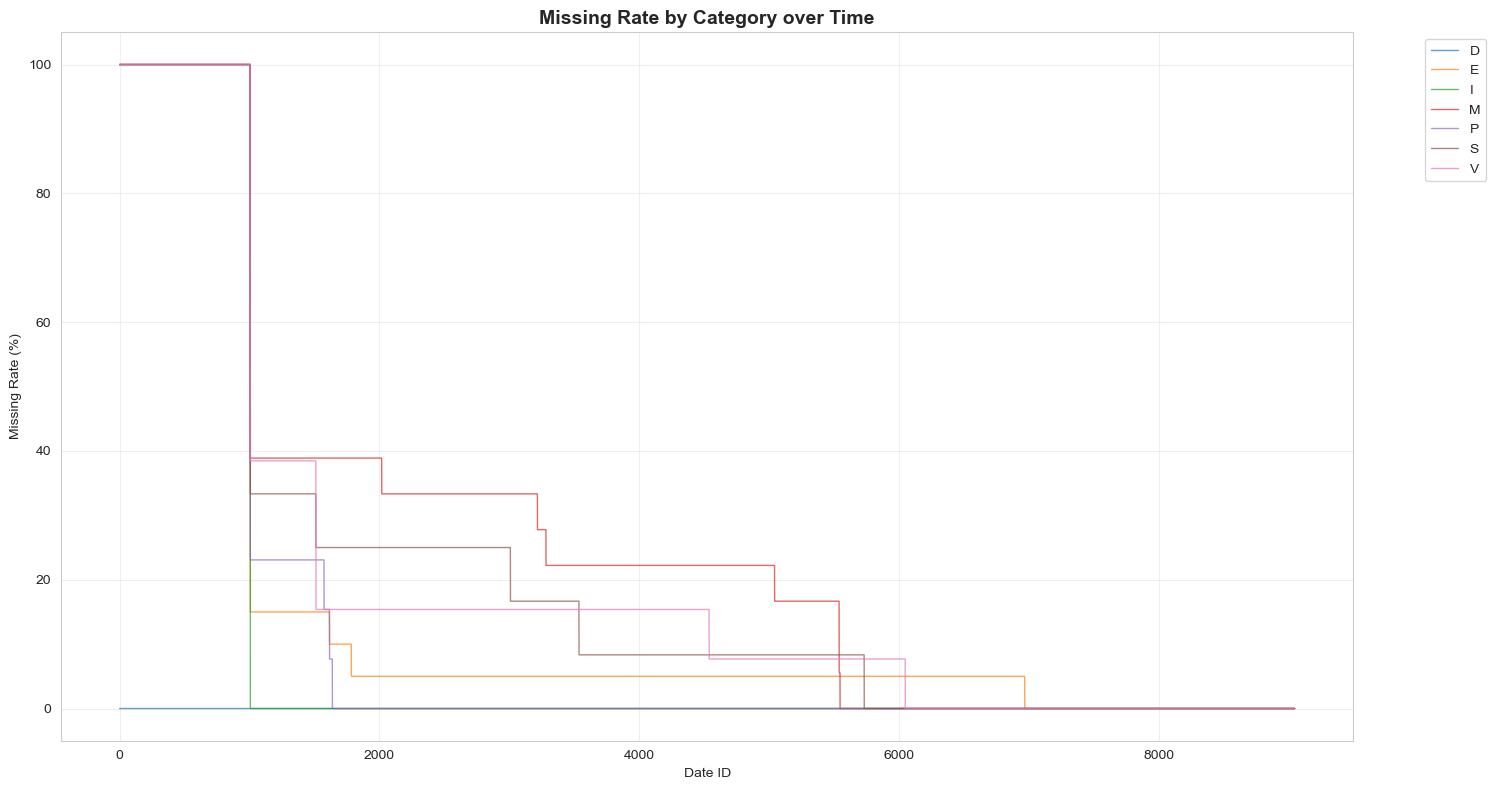

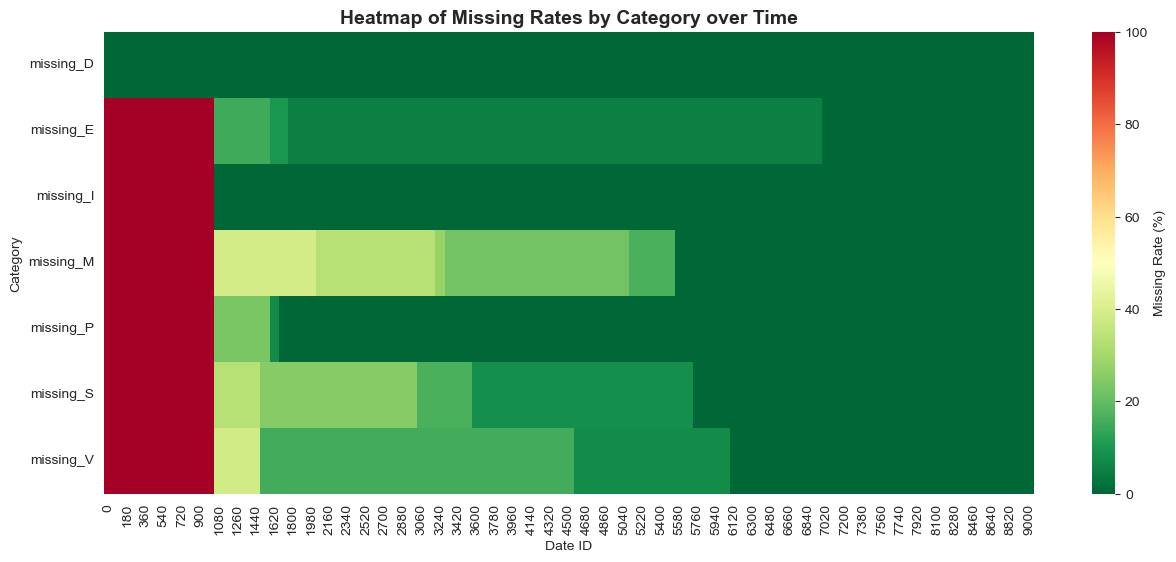

In [52]:
# Visual: Missing Rate by Category over Time
plt.figure(figsize=(15, 8))

for cat_name in feature_categories.keys():
    plt.plot(daily_df['date_id'], daily_df[f'missing_{cat_name}'], label=cat_name, linewidth=1, alpha=0.7)

plt.title('Missing Rate by Category over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date ID')
plt.ylabel('Missing Rate (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap Visualization
plt.figure(figsize=(15, 6))
# Downsample for heatmap if too many dates (e.g., sample every 10th day)
sample_step = max(1, len(daily_df) // 100)
heatmap_data = daily_df.iloc[::sample_step].set_index('date_id')[[f'missing_{cat}' for cat in feature_categories.keys()]].T

sns.heatmap(heatmap_data, cmap='RdYlGn_r', cbar_kws={'label': 'Missing Rate (%)'})
plt.title('Heatmap of Missing Rates by Category over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date ID')
plt.ylabel('Category')
plt.yticks(rotation=0)
plt.show()

In [53]:
# Categorical Feature Missing Analysis
print("Detailed Missing Analysis by Category:")
print("-" * 60)
print(f"{'Category':<10} {'Features':<10} {'Avg Missing':<15} {'Max Missing Feature':<25}")
print("-" * 60)

for idx, row in category_df.iterrows():
    cat = row['category']
    feats = feature_categories[cat]
    cat_missing_stats = missing_stats[missing_stats['feature'].isin(feats)]
    
    max_feat = "None"
    max_pct = 0
    if not cat_missing_stats.empty:
        max_feat = cat_missing_stats.iloc[0]['feature']
        max_pct = cat_missing_stats.iloc[0]['missing_pct']
        
    print(f"{cat:<10} {row['count']:<10} {row['missing_pct']:<14.2f}% {max_feat} ({max_pct:.1f}%)")

Detailed Missing Analysis by Category:
------------------------------------------------------------
Category   Features   Avg Missing     Max Missing Feature      
------------------------------------------------------------
M          18         25.33         % M1 (61.3%)
S          12         20.11         % S3 (63.4%)
V          13         19.70         % V10 (66.9%)
E          20         15.18         % E7 (77.0%)
P          13         12.66         % P6 (18.1%)
I          9          11.12         % I1 (11.1%)
D          9          0.00          % None (0.0%)


## 3. Exploratory Data Analysis

In [54]:
# Time Range Analysis
print("Train Date Range:")
print(f"Start: {train['date_id'].min()}")
print(f"End: {train['date_id'].max()}")
print(f"Total Days: {len(train)}")

print("\nTest Date Range:")
print(f"Start: {test['date_id'].min()}")
print(f"End: {test['date_id'].max()}")
print(f"Total Days: {len(test)}")

Train Date Range:
Start: 0
End: 9047
Total Days: 9048

Test Date Range:
Start: 8980
End: 8989
Total Days: 10


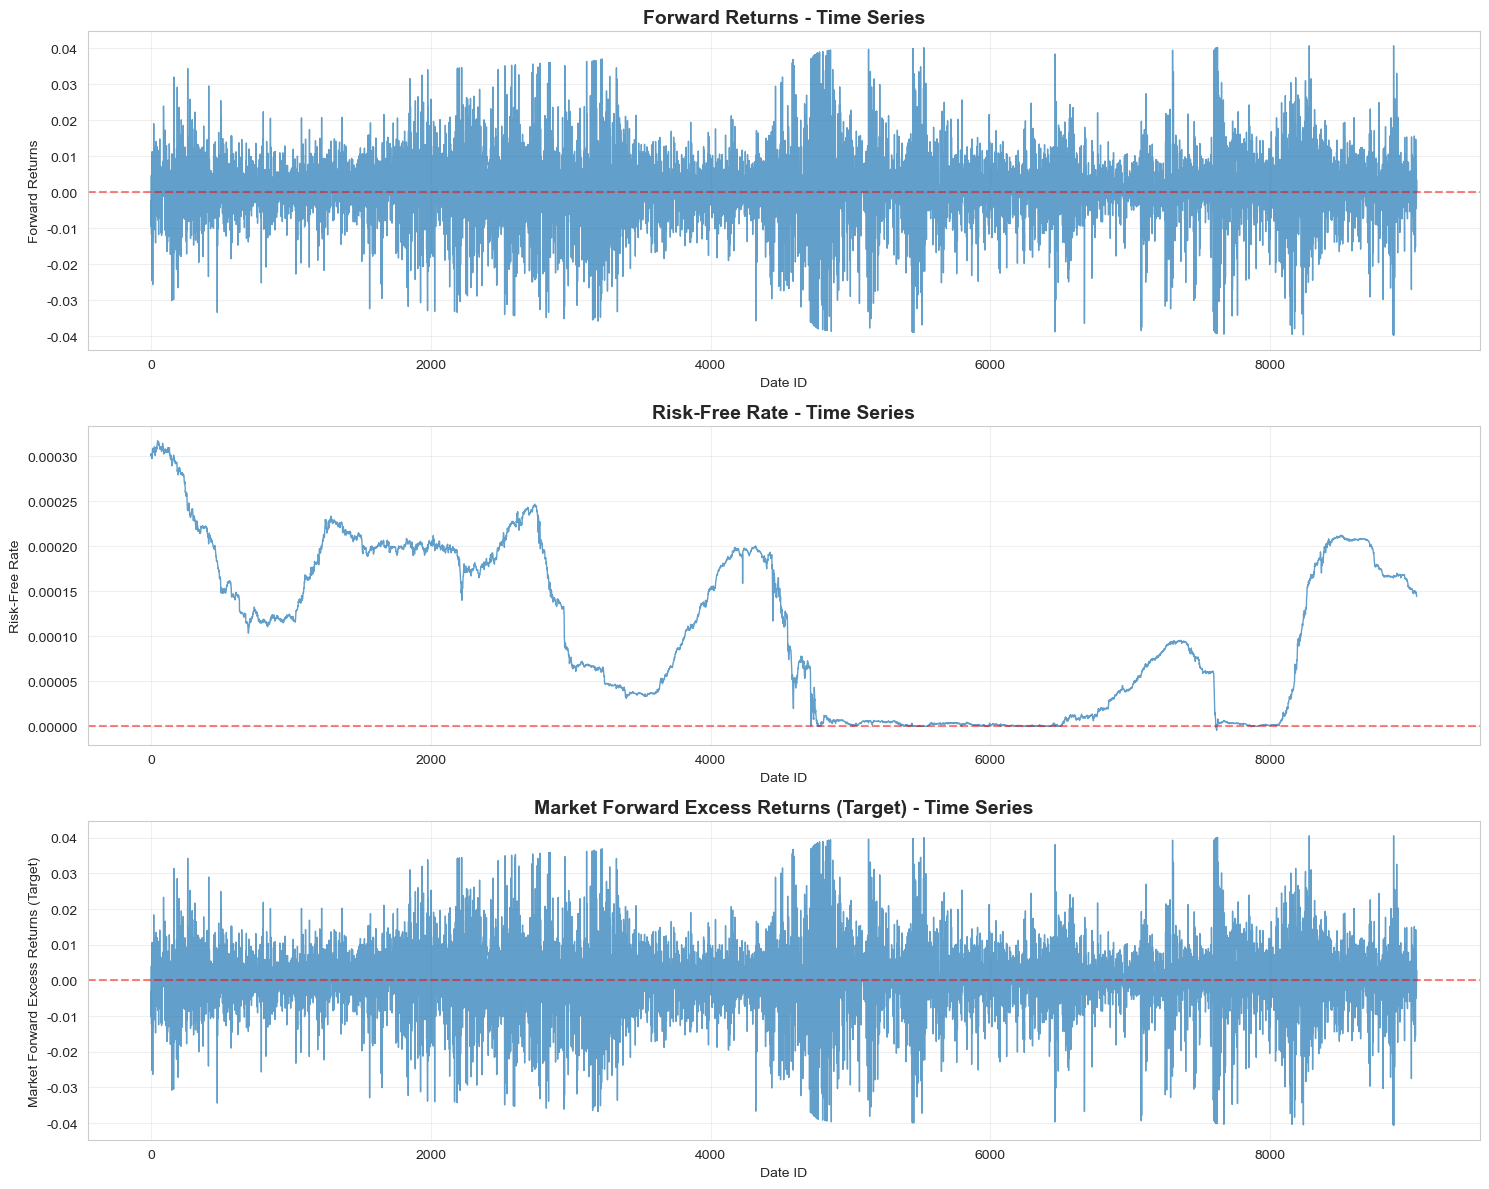

In [55]:
# Target Variables Time Series
target_vars = ['forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
target_names = ['Forward Returns', 'Risk-Free Rate', 'Market Forward Excess Returns (Target)']

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for idx, (var, name) in enumerate(zip(target_vars, target_names)):
    axes[idx].plot(train['date_id'], train[var], linewidth=1, alpha=0.7)
    axes[idx].set_title(f'{name} - Time Series', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Date ID')
    axes[idx].set_ylabel(name)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Plotting first batch of M features (total 18)...


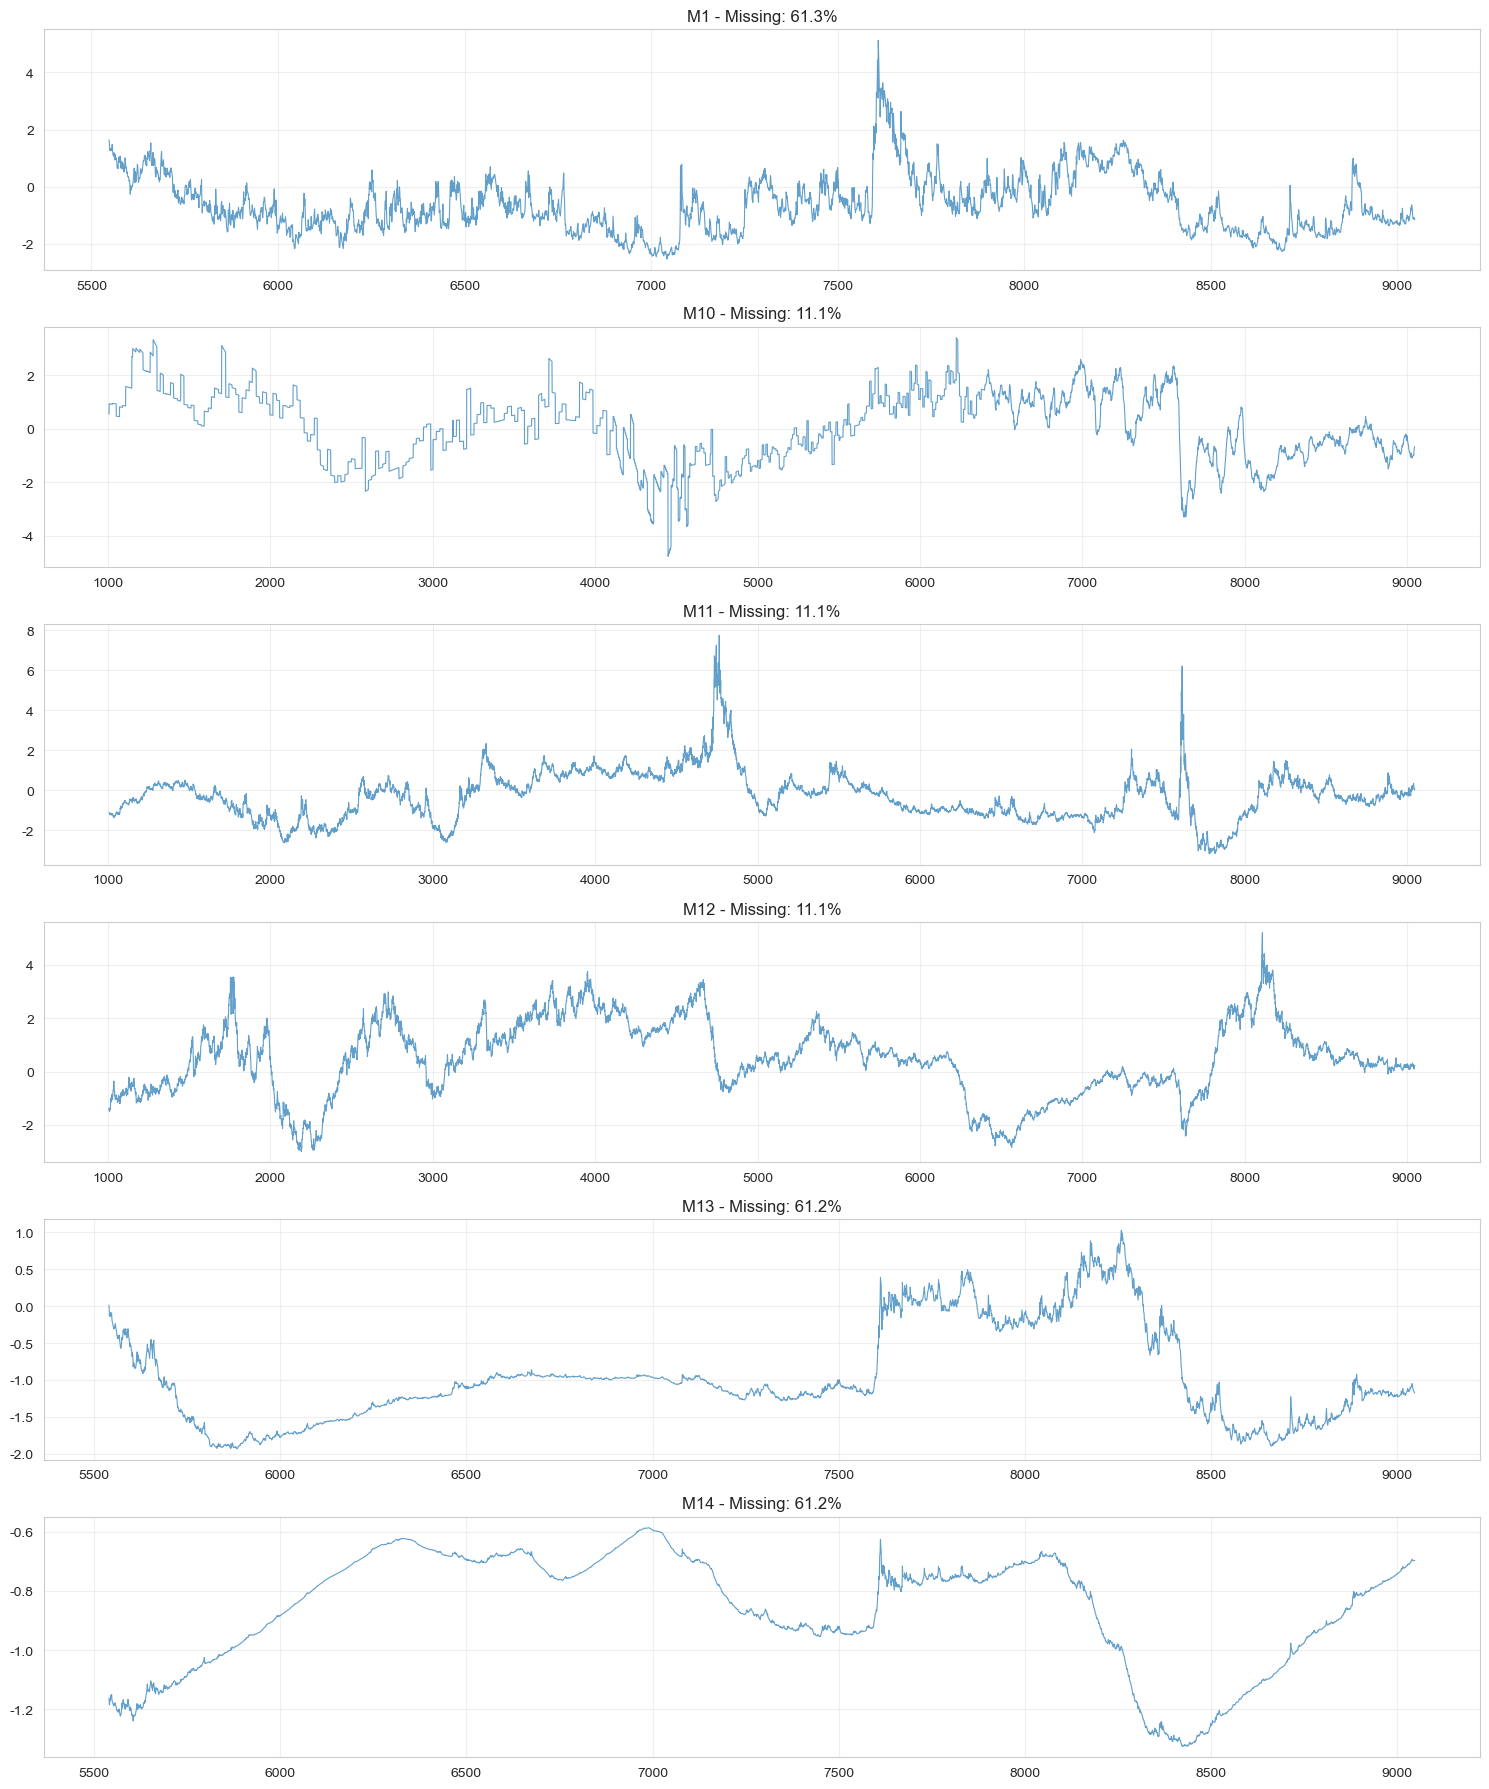

In [56]:
# Function to plot features in batches
def plot_feature_batch(features, batch_size=6):
    n_batches = (len(features) + batch_size - 1) // batch_size
    
    for i in range(n_batches):
        batch = features[i*batch_size : (i+1)*batch_size]
        n_rows = len(batch)
        
        fig, axes = plt.subplots(n_rows, 1, figsize=(15, 3*n_rows))
        if n_rows == 1: axes = [axes]
        
        for idx, col in enumerate(batch):
            data = train[['date_id', col]].dropna()
            axes[idx].plot(data['date_id'], data[col], linewidth=0.8, alpha=0.7)
            axes[idx].set_title(f'{col} - Missing: {train[col].isnull().mean()*100:.1f}%', fontsize=12)
            axes[idx].grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

# Example: Plot first 6 'M' features
m_features = sorted([c for c in train.columns if c.startswith('M') and train[c].dtype in ['float64', 'int64']])
print(f"Plotting first batch of M features (total {len(m_features)})...")
plot_feature_batch(m_features[:6])
# You can call plot_feature_batch(m_features) to see all

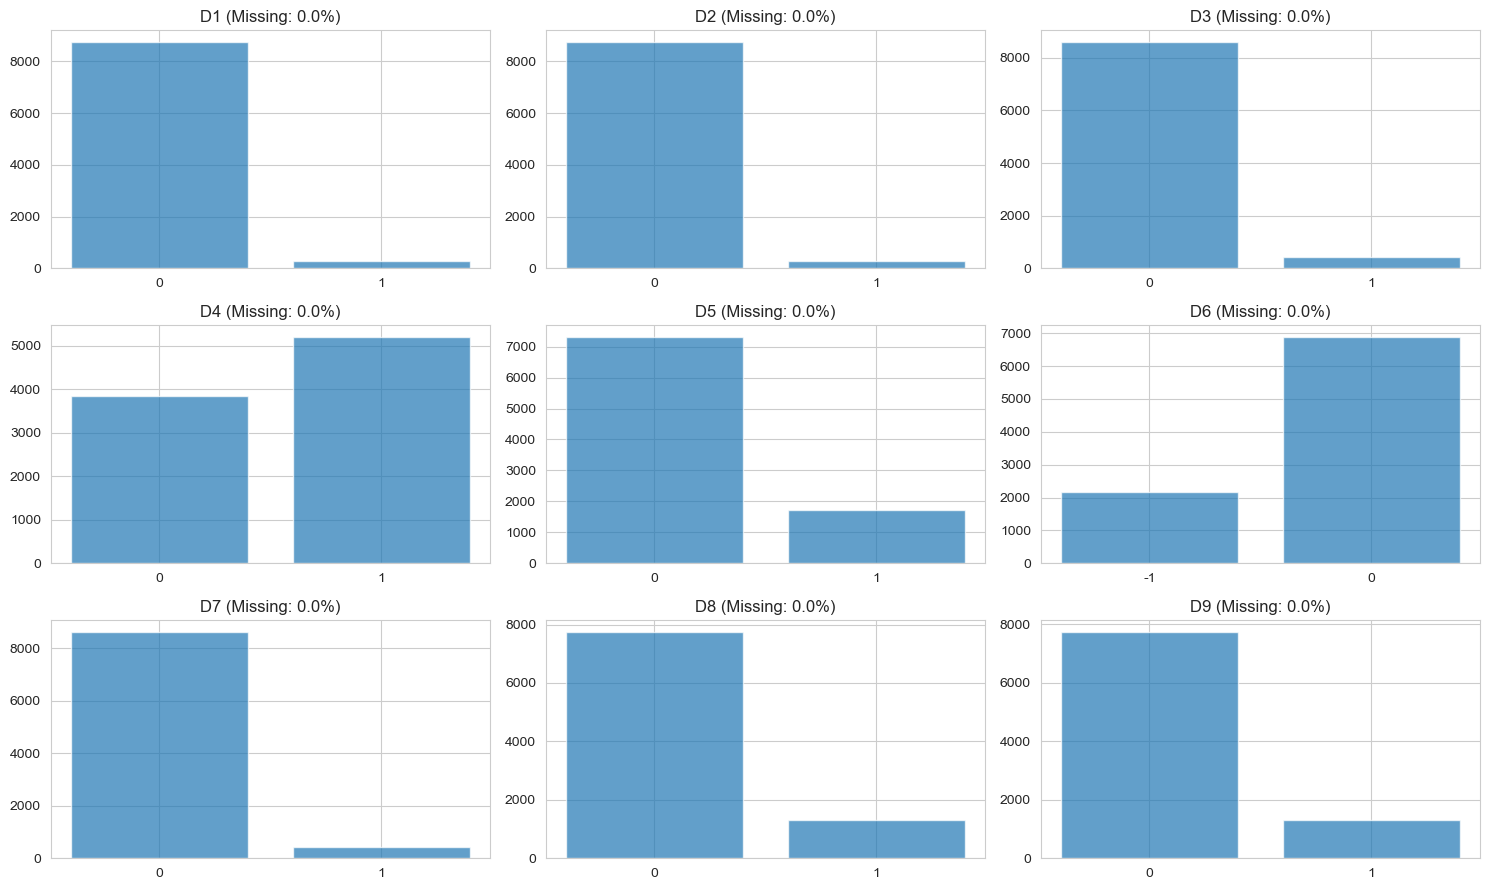

In [57]:
# Binary Features Distribution
binary_cols = sorted([col for col in train.columns if col.startswith('D')])

if binary_cols:
    n_cols = 3
    n_rows = (len(binary_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(binary_cols):
        val_counts = train[col].value_counts(dropna=False).sort_index()
        axes[idx].bar(range(len(val_counts)), val_counts.values, alpha=0.7)
        axes[idx].set_title(f'{col} (Missing: {train[col].isnull().mean()*100:.1f}%)')
        axes[idx].set_xticks(range(len(val_counts)))
        axes[idx].set_xticklabels([str(x) for x in val_counts.index])
    
    for idx in range(len(binary_cols), len(axes)):
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

In [58]:
# Correlation with Target
target = 'market_forward_excess_returns'
feature_cols = [col for col in train.columns 
                if col not in ['date_id', 'forward_returns', 'risk_free_rate', target]
                and train[col].notna().sum() > 100]

corr_results = []
print(f"Analyzing correlation for {len(feature_cols)} features...")

for col in feature_cols:
    # Use common non-NaN values
    mask = train[[col, target]].notna().all(axis=1)
    if mask.sum() < 50: continue
    
    corr, p_val = stats.pearsonr(train.loc[mask, col], train.loc[mask, target])
    corr_results.append({'feature': col, 'corr': corr, 'p_value': p_val})

df_corr = pd.DataFrame(corr_results).sort_values('corr', key=abs, ascending=False)
print("Top 10 Correlated Features:")
display(df_corr.head(10))

Analyzing correlation for 94 features...
Top 10 Correlated Features:


,feature,corr,p_value
50,M4,-0.066632,2.216095e-09
85,V13,0.062378,5.966957e-08
38,M1,0.046433,5.998014e-03
76,S5,0.040009,5.123351e-04
73,S2,-0.038493,5.549728e-04
0,D1,0.033882,1.266937e-03
1,D2,0.033882,1.266937e-03
82,V10,0.032859,7.198944e-02
26,E7,-0.032230,1.418223e-01
48,M2,0.032166,1.403517e-02


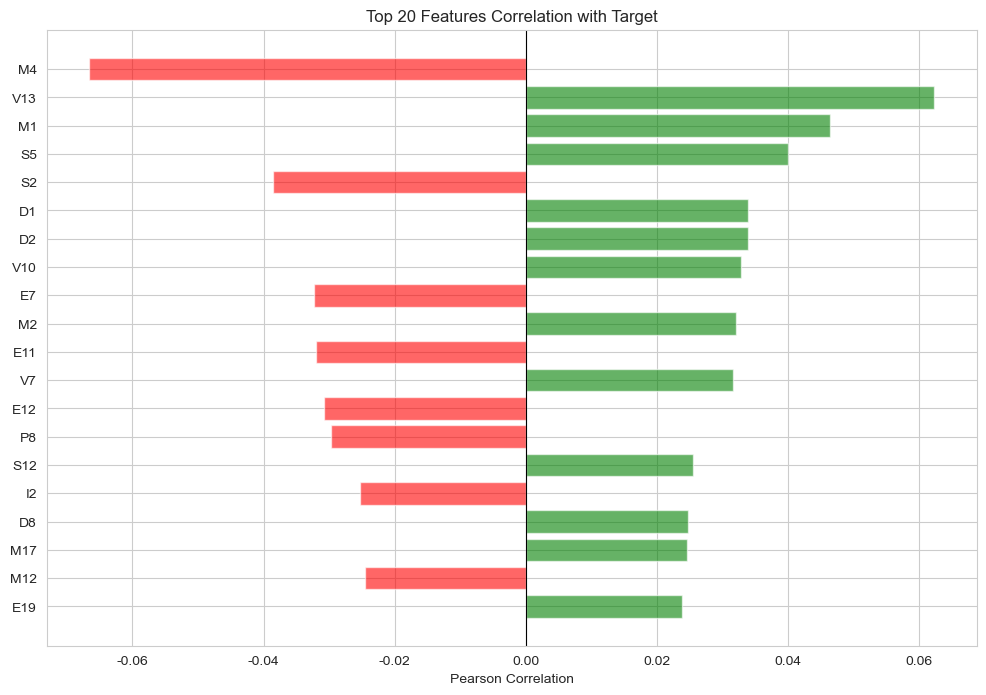

In [59]:
# Visual: Top 20 Correlations
top_20 = df_corr.head(20)
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in top_20['corr']]
plt.barh(range(len(top_20)), top_20['corr'], color=colors, alpha=0.6)
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Pearson Correlation')
plt.title('Top 20 Features Correlation with Target')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

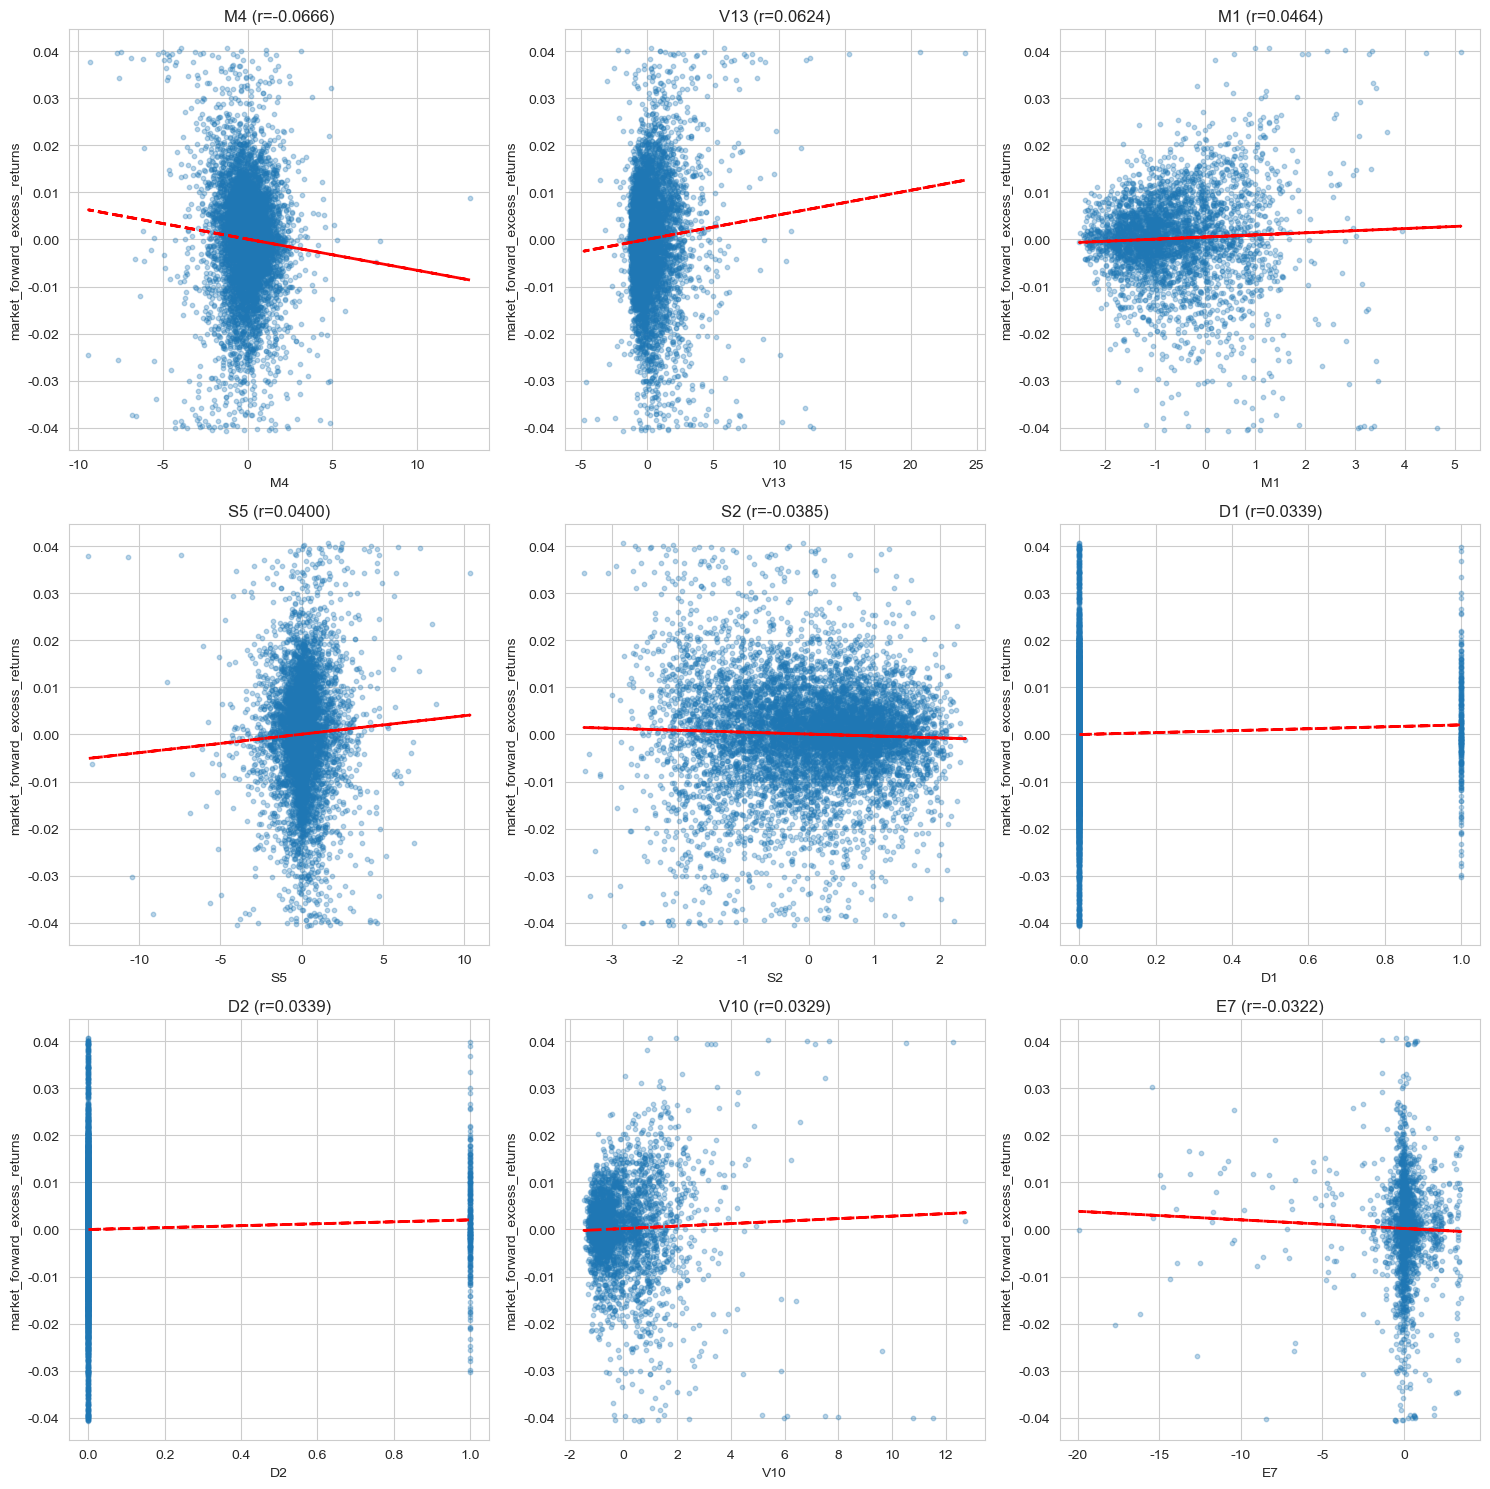

In [60]:
# Visual: Top 9 Scatter Plots
top_9 = df_corr.head(9)['feature'].tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, col in enumerate(top_9):
    mask = train[[col, target]].notna().all(axis=1)
    X = train.loc[mask, col]
    y = train.loc[mask, target]
    
    axes[idx].scatter(X, y, alpha=0.3, s=10)
    
    # Trend line
    if len(X) > 1:
        z = np.polyfit(X, y, 1)
        p = np.poly1d(z)
        axes[idx].plot(X, p(X), "r--", linewidth=2)
        
    corr = df_corr[df_corr['feature']==col]['corr'].values[0]
    axes[idx].set_title(f'{col} (r={corr:.4f})')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel(target)

plt.tight_layout()
plt.show()

Calculating correlation matrix for all features...


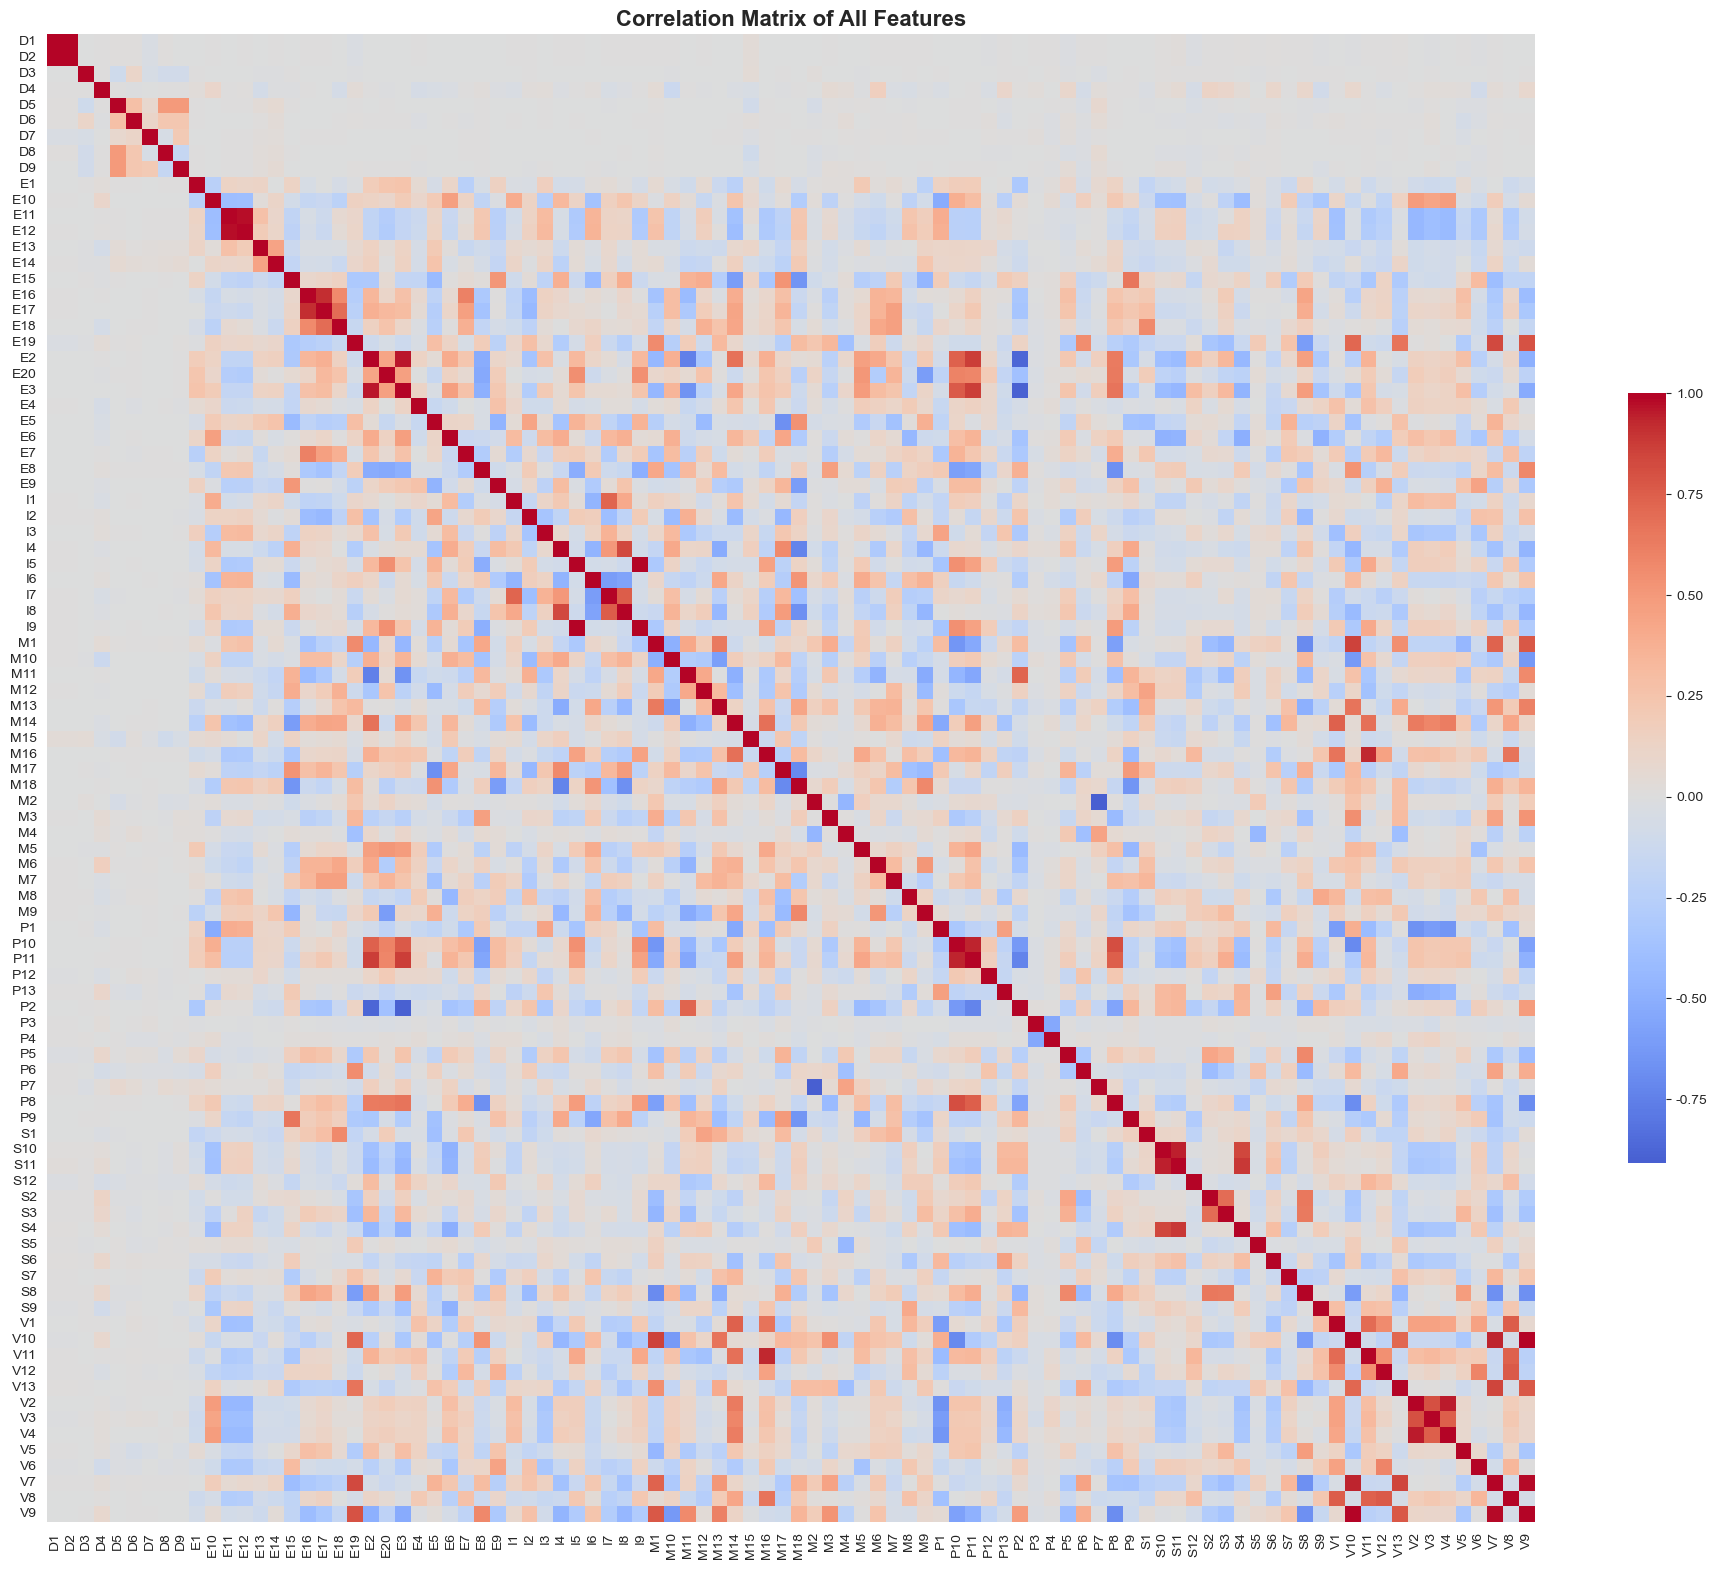

In [61]:
# Correlation Matrix of All Features
# Displaying heatmap for all features to show global patterns. Numbers (annotations) are hidden for clarity.
print("Calculating correlation matrix for all features...")
# Use all feature columns defined in Cell 17
if len(feature_cols) > 1:
    corr_mat = train[feature_cols].corr()
    
    plt.figure(figsize=(24, 20))
    # annot=False: Show color only
    sns.heatmap(corr_mat, annot=False, cmap='coolwarm', center=0, square=True, cbar_kws={"shrink": .5})
    plt.title('Correlation Matrix of All Features', fontsize=16, fontweight='bold')
    plt.yticks(rotation=0)
    plt.show()

## 4. PCA Analysis

In [62]:
# Data Prep for PCA
# Use features, fill missing with median, standardize
X_pca_input = train[feature_cols].copy()
X_pca_input = X_pca_input.fillna(X_pca_input.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)
print("Data scaled and ready for PCA.")

Data scaled and ready for PCA.


In [63]:
# Run PCA
pca = PCA()
X_pca_result = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

Components for 90% variance: 40
Components for 95% variance: 51


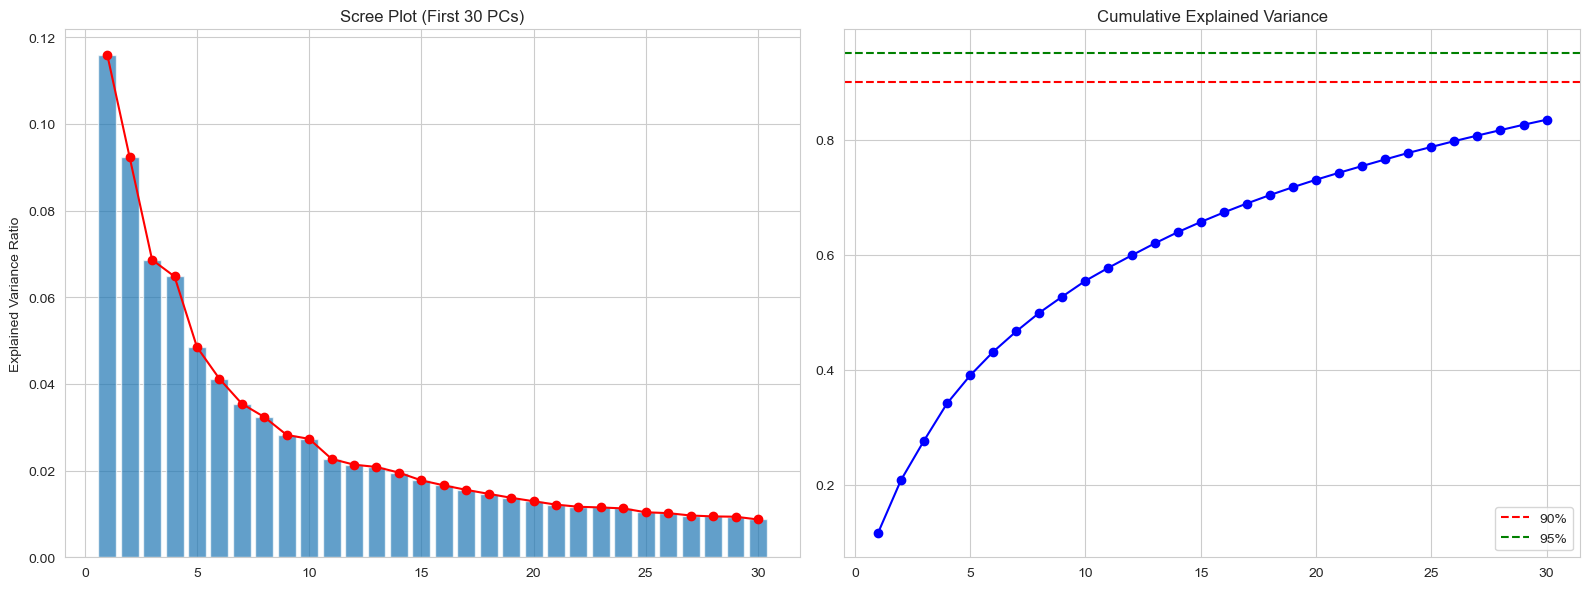

In [64]:
# Visual: Scree Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

n_show = min(30, len(explained_var))
ax1.bar(range(1, n_show+1), explained_var[:n_show], alpha=0.7)
ax1.plot(range(1, n_show+1), explained_var[:n_show], 'r-o')
ax1.set_title(f'Scree Plot (First {n_show} PCs)')
ax1.set_ylabel('Explained Variance Ratio')

ax2.plot(range(1, n_show+1), cum_var[:n_show], 'b-o')
ax2.axhline(0.9, color='r', linestyle='--', label='90%')
ax2.axhline(0.95, color='g', linestyle='--', label='95%')
ax2.legend()
ax2.set_title('Cumulative Explained Variance')

plt.tight_layout()
plt.show()

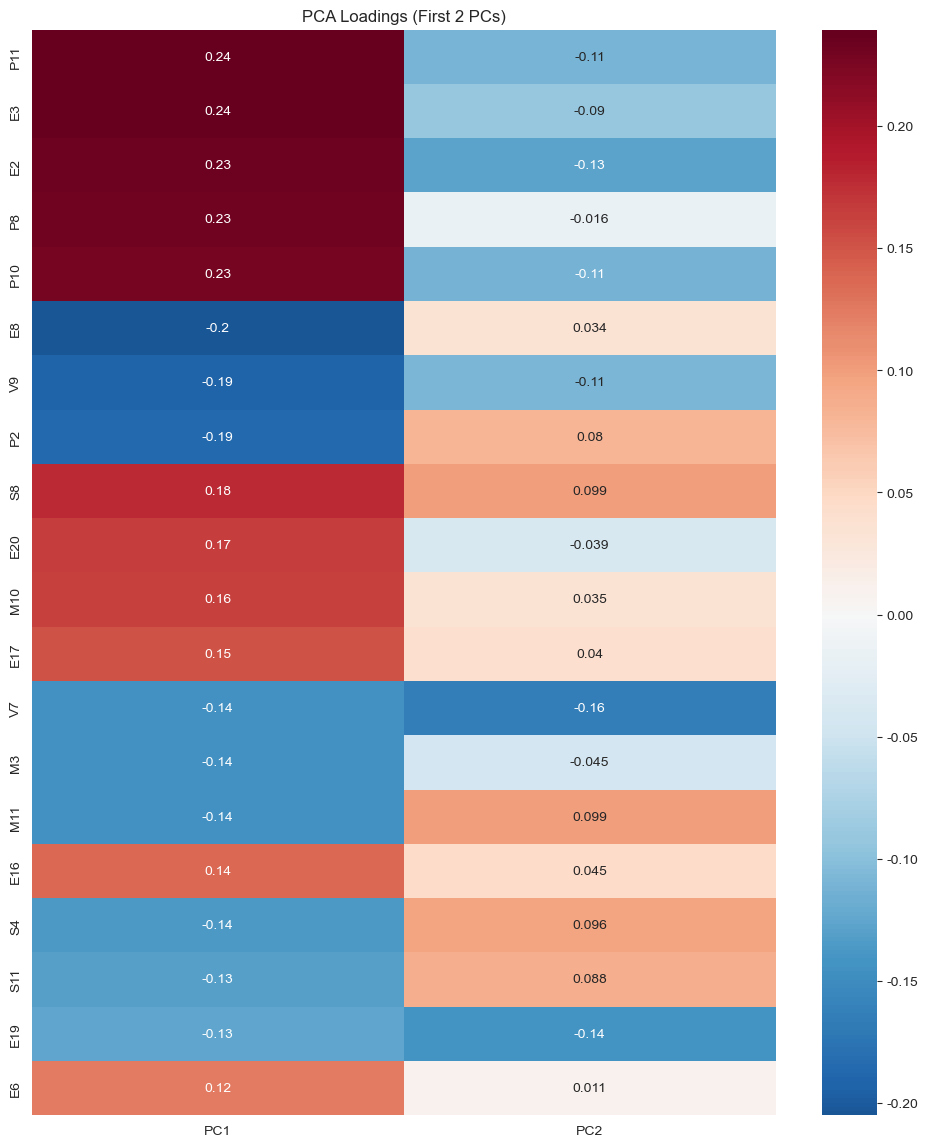

In [65]:
# Visual: Loadings Heatmap (First 2 PCs)
loadings = pd.DataFrame(
    pca.components_[:2].T, 
    columns=['PC1', 'PC2'], 
    index=feature_cols
)

plt.figure(figsize=(12, max(8, len(feature_cols)*0.15)))
# If too many features, create a simpler heatmap or just top features
if len(feature_cols) > 50:
    # Show top 20 features by loading magnitude for PC1
    top_features = loadings['PC1'].abs().sort_values(ascending=False).head(20).index
    sns.heatmap(loadings.loc[top_features], annot=True, cmap='RdBu_r', center=0)
else:
    sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0)

plt.title('PCA Loadings (First 2 PCs)')
plt.show()

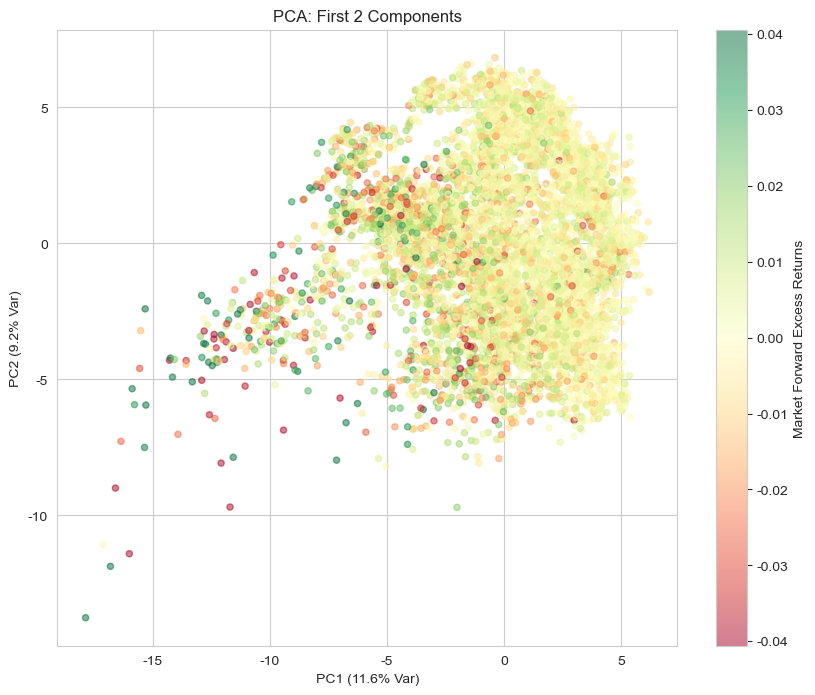

In [66]:
# Visual: PCA 2D Scatter
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_result[:, 0], X_pca_result[:, 1], 
            c=train['market_forward_excess_returns'], 
            cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(label='Market Forward Excess Returns')
plt.xlabel(f'PC1 ({explained_var[0]:.1%} Var)')
plt.ylabel(f'PC2 ({explained_var[1]:.1%} Var)')
plt.title('PCA: First 2 Components')
plt.show()

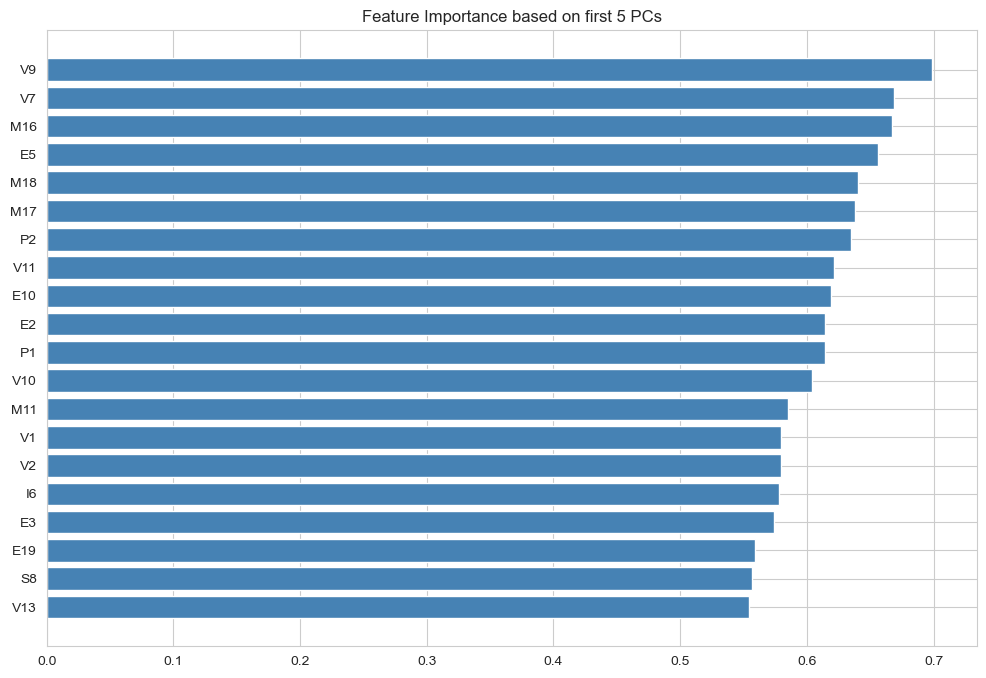

In [67]:
# Visual: PCA Feature Importance
# Sum of absolute loadings across first 5 PCs
n_pcs = min(5, len(explained_var))
importance = np.abs(pca.components_[:n_pcs]).sum(axis=0)
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importance}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_imp = imp_df.head(20)
plt.barh(range(len(top_imp)), top_imp['importance'], color='steelblue')
plt.yticks(range(len(top_imp)), top_imp['feature'])
plt.title(f'Feature Importance based on first {n_pcs} PCs')
plt.gca().invert_yaxis()
plt.show()

## 5. Financial Statistical Analysis (New)

In [68]:
# Descriptive Statistics (Table 1 for Paper)
# Calculating Mean, Std, Min, Max, Skewness, Kurtosis for Key Features
stats_cols = ['market_forward_excess_returns'] + feature_cols[:20] # Top 20 features for brevity
desc_stats = []

for col in stats_cols:
    data = train[col].dropna()
    desc_stats.append({
        'Feature': col,
        'Mean': data.mean(),
        'Std': data.std(),
        'Min': data.min(),
        'Max': data.max(),
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data)
    })

df_desc = pd.DataFrame(desc_stats)
print("Descriptive Statistics for Target and Top Features:")
display(df_desc.round(4))

Descriptive Statistics for Target and Top Features:


,Feature,Mean,Std,Min,Max,Skewness,Kurtosis
0,market_forward_excess_returns,0.0001,0.0106,-0.0406,0.0406,-0.1800,2.2426
1,D1,0.0316,0.1750,0.0000,1.0000,5.3543,26.6690
2,D2,0.0316,0.1750,0.0000,1.0000,5.3543,26.6690
3,D3,0.0479,0.2135,0.0000,1.0000,4.2363,15.9463
4,D4,0.5753,0.4943,0.0000,1.0000,-0.3045,-1.9073
5,D5,0.1908,0.3929,0.0000,1.0000,1.5741,0.4779
6,D6,-0.2382,0.4260,-1.0000,0.0000,-1.2293,-0.4888
7,D7,0.0458,0.2090,0.0000,1.0000,4.3478,16.9030
8,D8,0.1429,0.3500,0.0000,1.0000,2.0407,2.1644
9,D9,0.1432,0.3503,0.0000,1.0000,2.0368,2.1487


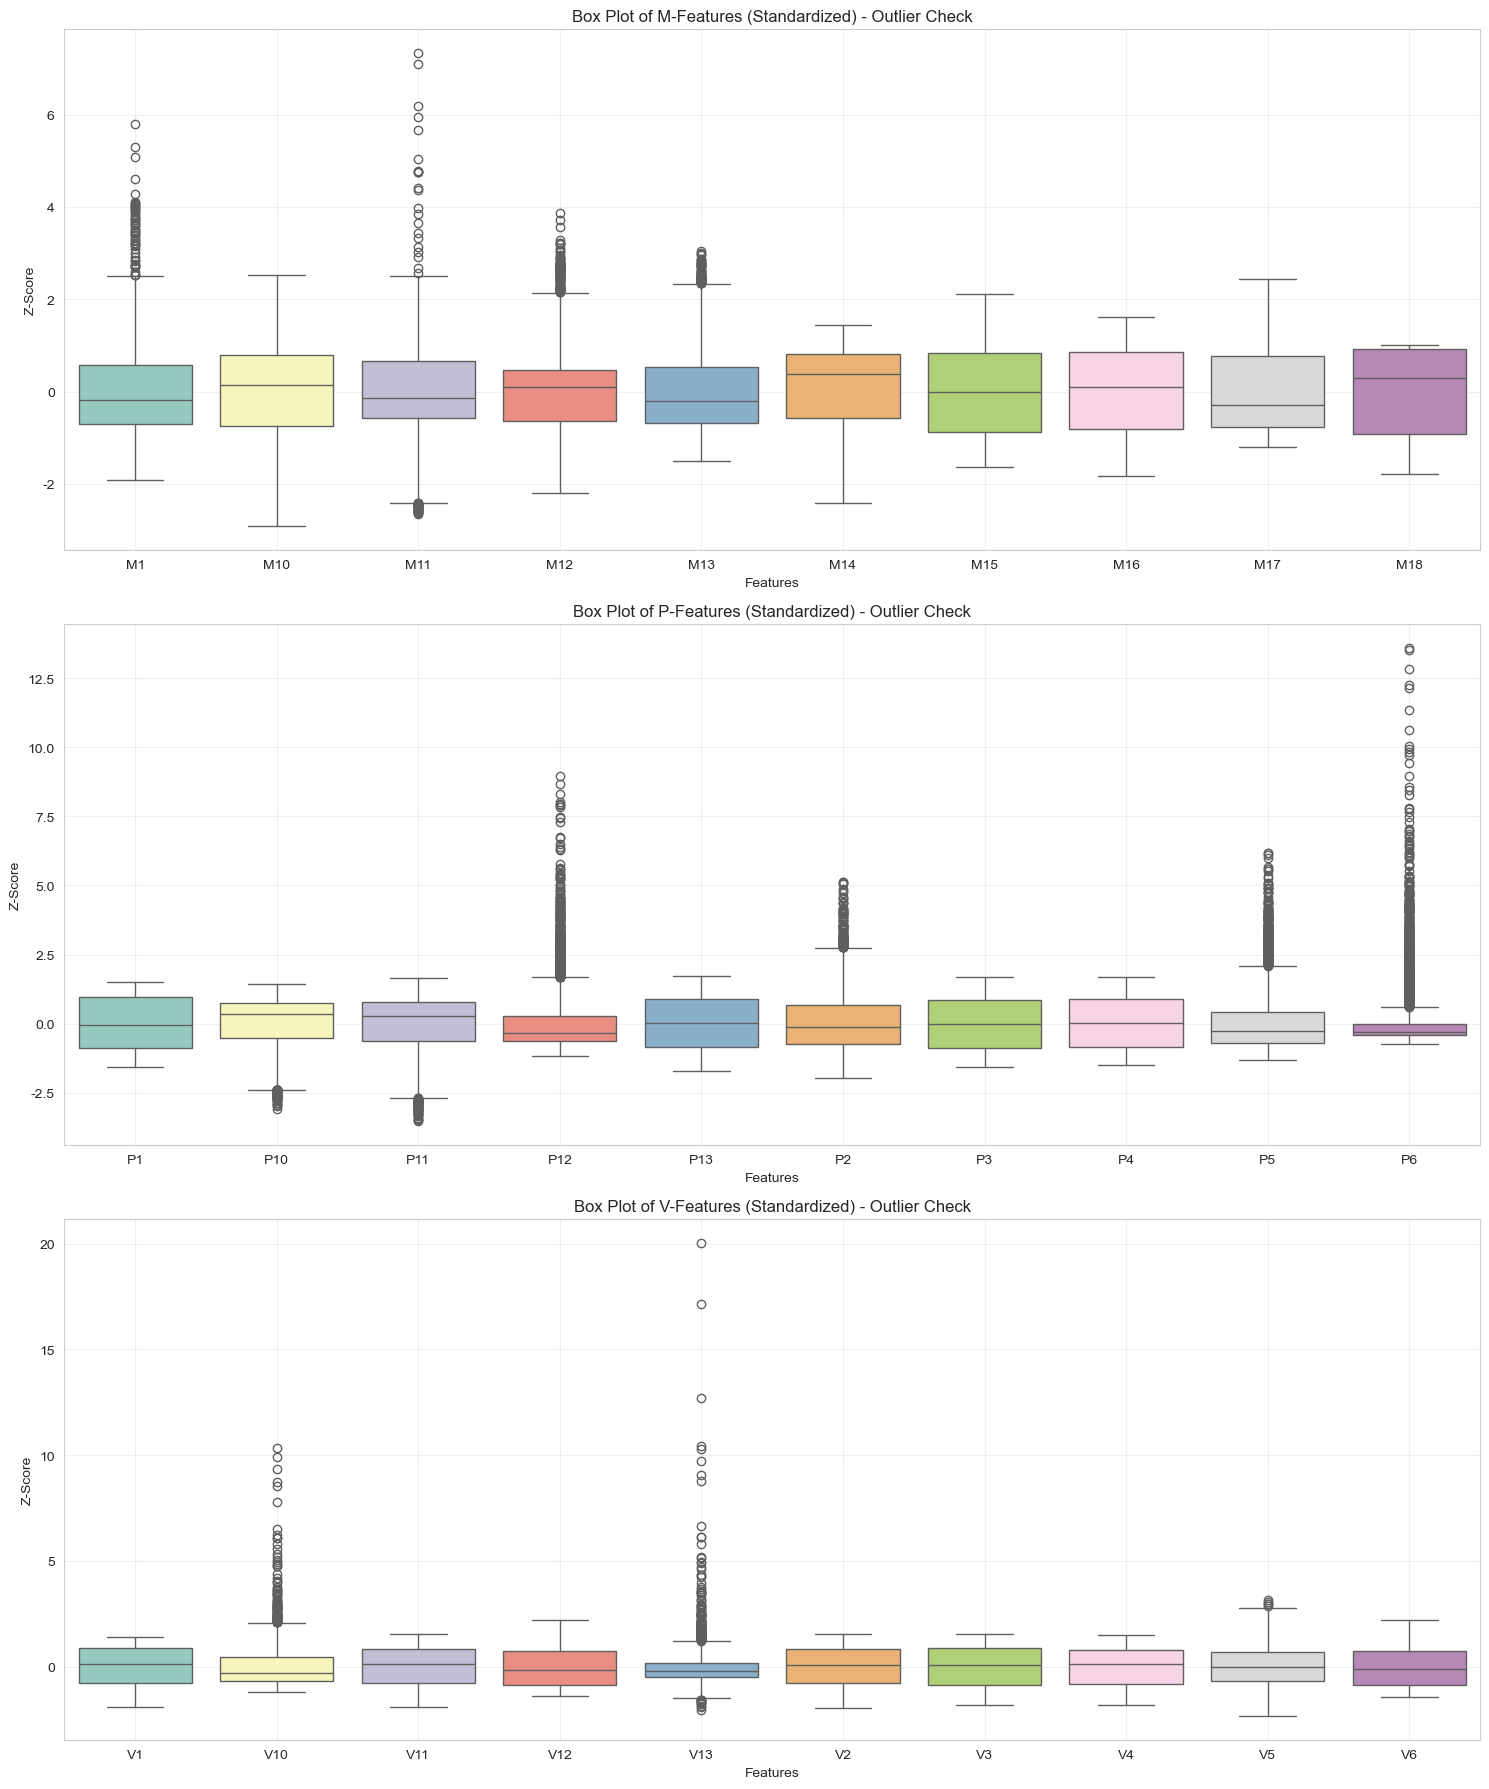

In [69]:
# Visual: Box Plots for Outlier Detection
# Plotting Box Plots for different feature categories to identify outliers
cats_to_plot = ['M', 'P', 'V'] # Key categories
fig, axes = plt.subplots(len(cats_to_plot), 1, figsize=(15, 6*len(cats_to_plot)))
if len(cats_to_plot) == 1: axes = [axes]

for idx, cat in enumerate(cats_to_plot):
    cat_feats = [c for c in train.columns if c.startswith(cat) and train[c].dtype in ['float64', 'int64']][:10] # Top 10 per cat
    if not cat_feats: continue
    
    data = train[cat_feats].dropna()
    # Standardize for better visualization comparison
    data_std = (data - data.mean()) / data.std()
    
    sns.boxplot(data=data_std, ax=axes[idx], palette='Set3')
    axes[idx].set_title(f'Box Plot of {cat}-Features (Standardized) - Outlier Check')
    axes[idx].set_xlabel('Features')
    axes[idx].set_ylabel('Z-Score')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

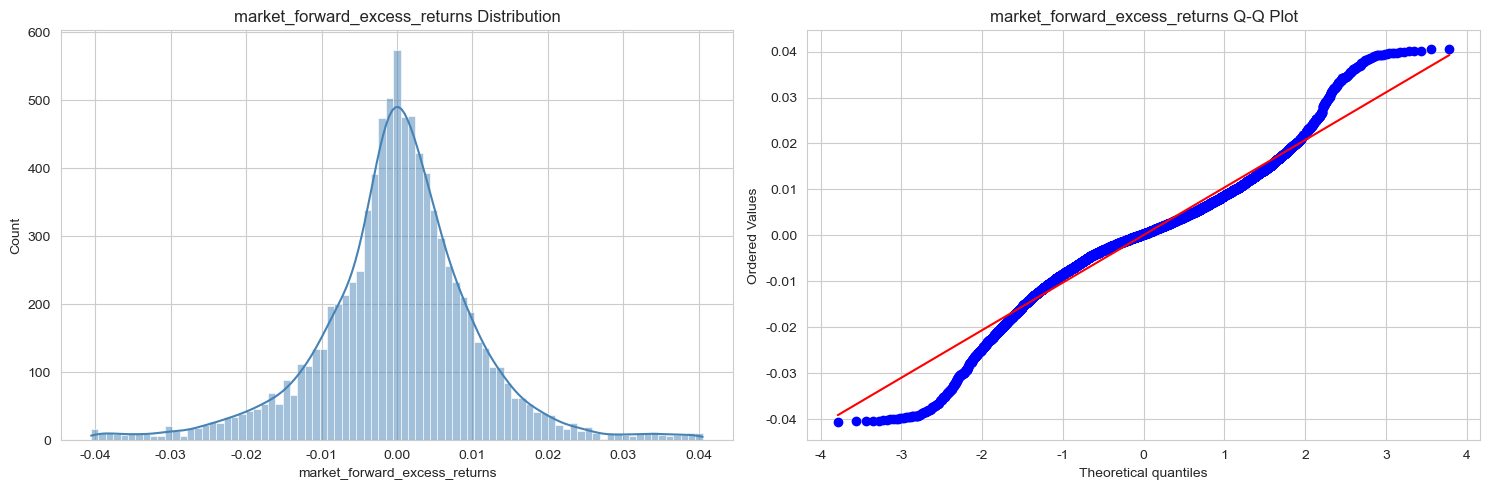

Kurtosis and Skewness:
market_forward_excess_returns: Skew=-0.1800, Kurtosis=2.2426


In [70]:
# Visual: Histograms & KDE (Distribution Analysis)
# Analyzing Fat Tails and Skewness
features_to_plot = ['market_forward_excess_returns']

fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(15, 5*len(features_to_plot)))
if len(features_to_plot) == 1: axes = axes.reshape(1, -1)

for idx, col in enumerate(features_to_plot):
    data = train[col].dropna()
    
    # Histogram
    sns.histplot(data, kde=True, ax=axes[idx, 0], color='steelblue')
    axes[idx, 0].set_title(f'{col} Distribution')
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[idx, 1])
    axes[idx, 1].set_title(f'{col} Q-Q Plot')

plt.tight_layout()
plt.show()

print("Kurtosis and Skewness:")
for col in features_to_plot:
    data = train[col].dropna()
    print(f"{col}: Skew={stats.skew(data):.4f}, Kurtosis={stats.kurtosis(data):.4f}")

In [71]:
# Stationarity Test (Augmented Dickey-Fuller)
def test_stationarity(timeseries, name):
    # Perform Dickey-Fuller test:
    print(f'Results of Dickey-Fuller Test for {name}:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    print(f"Is Stationary (p<0.05)? {dftest[1] < 0.05}\n")

# Test Target
target_data = train['market_forward_excess_returns'].dropna()
test_stationarity(target_data, 'Target (market_forward_excess_returns)')

# Test a Feature (e.g., M0 or similar)
m_feats = [c for c in train.columns if c.startswith('M') and train[c].dtype in ['float64', 'int64']]
if m_feats:
    feat_data = train[m_feats[0]].dropna()
    test_stationarity(feat_data, m_feats[0])

Results of Dickey-Fuller Test for Target (market_forward_excess_returns):
Test Statistic                -1.757052e+01
p-value                        4.053695e-30
#Lags Used                     3.300000e+01
Number of Observations Used    9.014000e+03
Critical Value (1%)           -3.431076e+00
Critical Value (5%)           -2.861861e+00
Critical Value (10%)          -2.566941e+00
dtype: float64
Is Stationary (p<0.05)? True

Results of Dickey-Fuller Test for M1:
Test Statistic                   -5.162667
p-value                           0.000010
#Lags Used                        4.000000
Number of Observations Used    3496.000000
Critical Value (1%)              -3.432222
Critical Value (5%)              -2.862367
Critical Value (10%)             -2.567210
dtype: float64
Is Stationary (p<0.05)? True



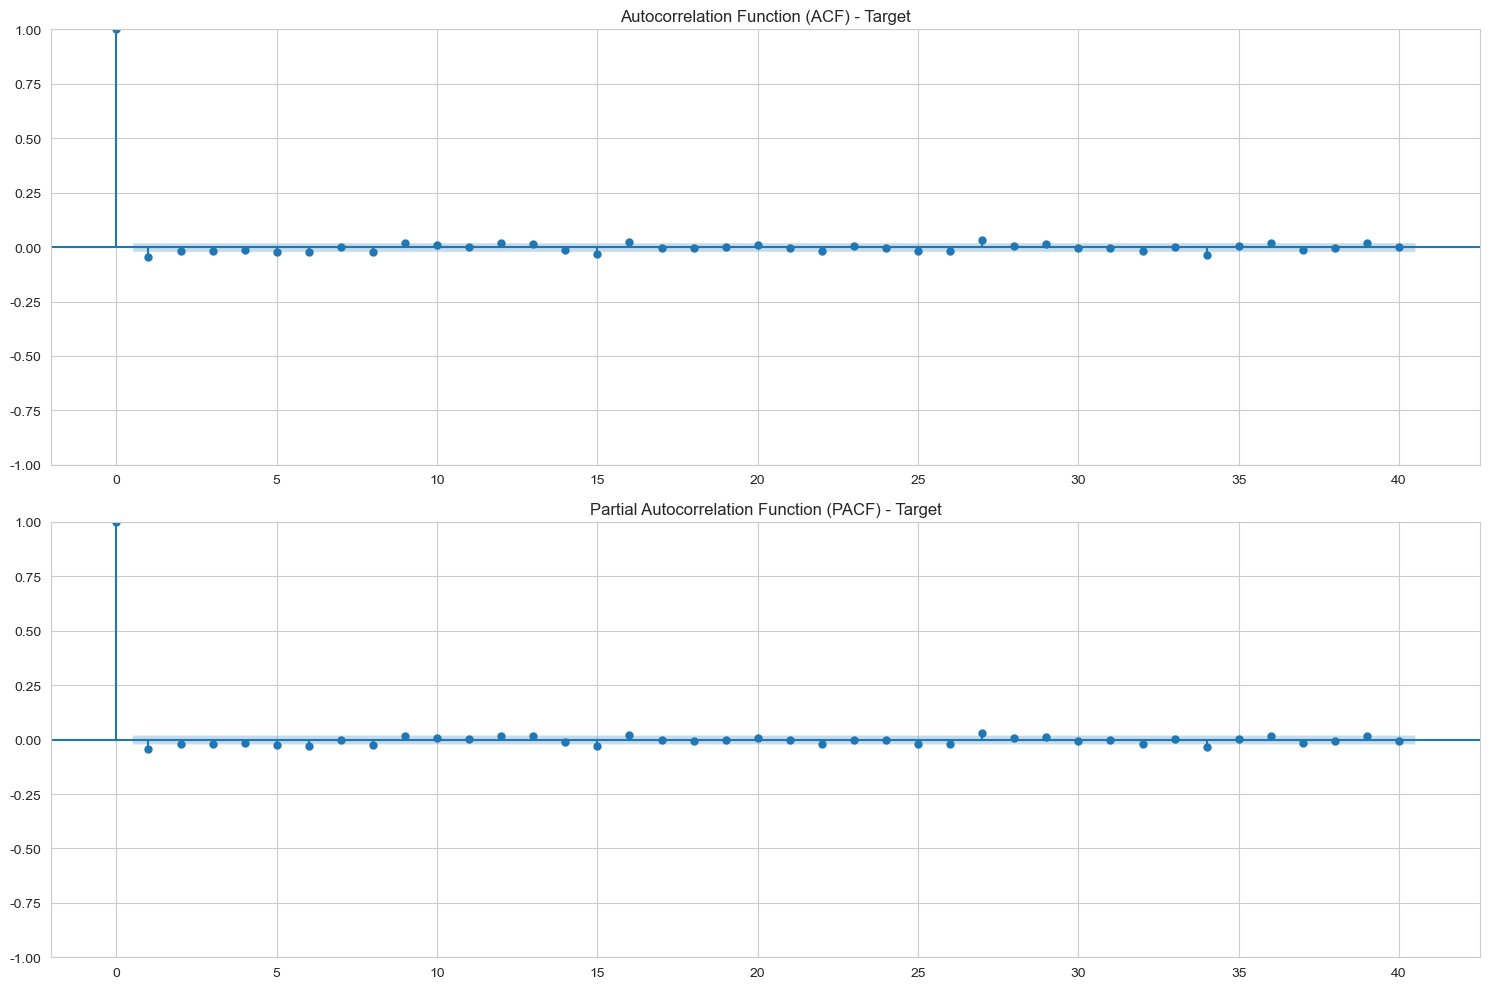

In [72]:
# Temporal Dynamics: Autocorrelation (ACF) & Partial Autocorrelation (PACF)
# Check for momentum or mean reversion
target_data = train['market_forward_excess_returns'].dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(target_data, lags=40, ax=ax1, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF) - Target')

plot_pacf(target_data, lags=40, ax=ax2, alpha=0.05)
ax2.set_title('Partial Autocorrelation Function (PACF) - Target')

plt.tight_layout()
plt.show()

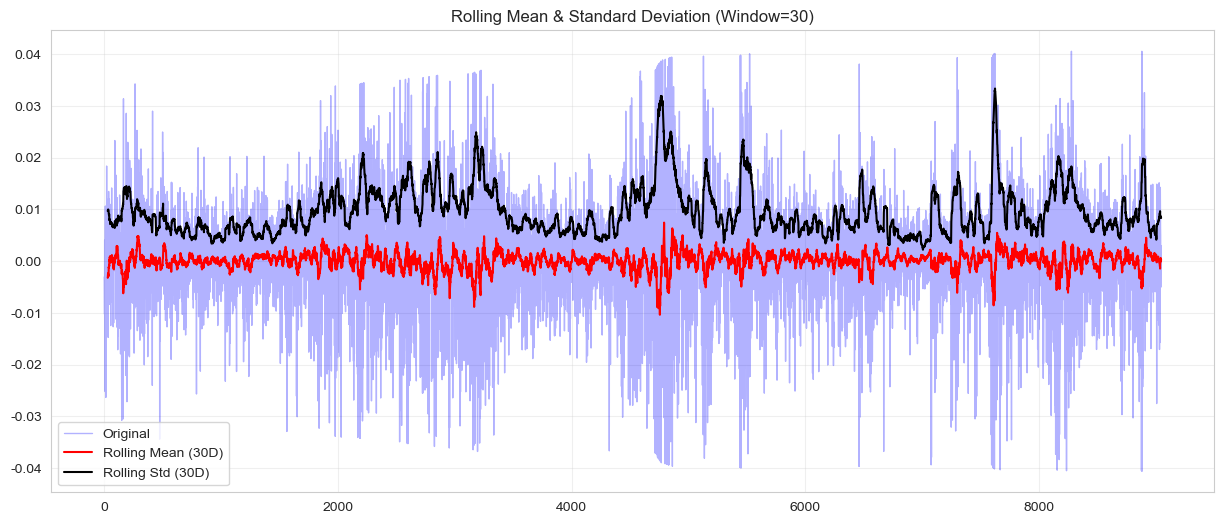

In [73]:
# Rolling Statistics (Volatility Analysis)
# 30-day Rolling Mean and Standard Deviation
window = 30
target_data = train[['date_id', 'market_forward_excess_returns']].dropna().set_index('date_id')
rolling_mean = target_data.rolling(window=window).mean()
rolling_std = target_data.rolling(window=window).std()

plt.figure(figsize=(15, 6))
plt.plot(target_data, color='blue', label='Original', alpha=0.3, linewidth=1)
plt.plot(rolling_mean, color='red', label=f'Rolling Mean ({window}D)', linewidth=1.5)
plt.plot(rolling_std, color='black', label=f'Rolling Std ({window}D)', linewidth=1.5)
plt.legend(loc='best')
plt.title(f'Rolling Mean & Standard Deviation (Window={window})')
plt.grid(True, alpha=0.3)
plt.show()

## Target Variable Analysis
Calculating descriptive statistics for `market_forward_excess_returns`.

Target Variable Descriptive Statistics:
count    9048.000000
mean        0.000052
std         0.010552
min        -0.040582
25%        -0.004751
50%         0.000257
75%         0.005469
max         0.040551
Name: market_forward_excess_returns, dtype: float64
Skewness: -0.18002441611783004
Kurtosis: 2.2444742582210644


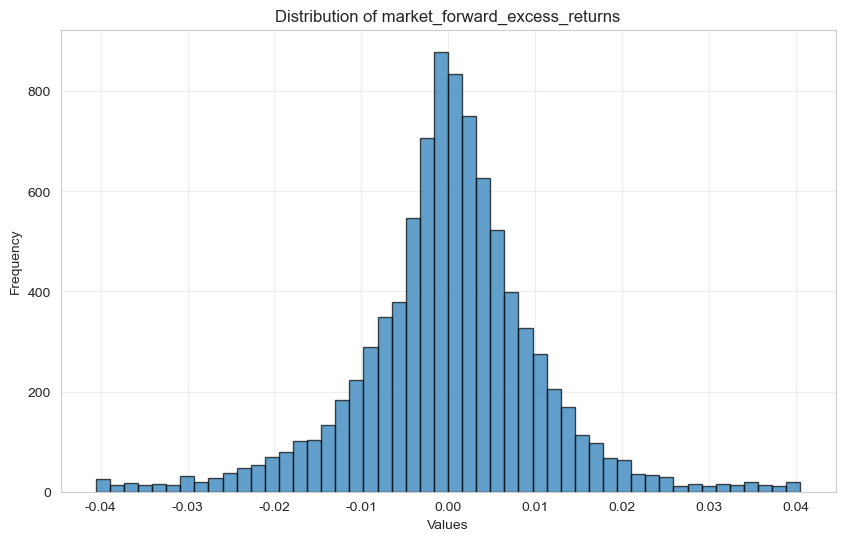

In [74]:
# Target Descriptive Statistics
target_col = 'market_forward_excess_returns'
if target_col in train.columns:
    desc_stats = train[target_col].describe()
    skewness = train[target_col].skew()
    kurtosis = train[target_col].kurt()
    print('Target Variable Descriptive Statistics:')
    print(desc_stats)
    print(f'Skewness: {skewness}')
    print(f'Kurtosis: {kurtosis}')
    
    # Histogram
    plt.figure(figsize=(10, 6))
    plt.hist(train[target_col].dropna(), bins=50, edgecolor='k', alpha=0.7)
    plt.title(f'Distribution of {target_col}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Column '{target_col}' not found in DataFrame.")

## Feature Category Missingness Over Time (M and V)
Investigating if the missingness in 'M' and 'V' categories is structural (e.g., changing over time).

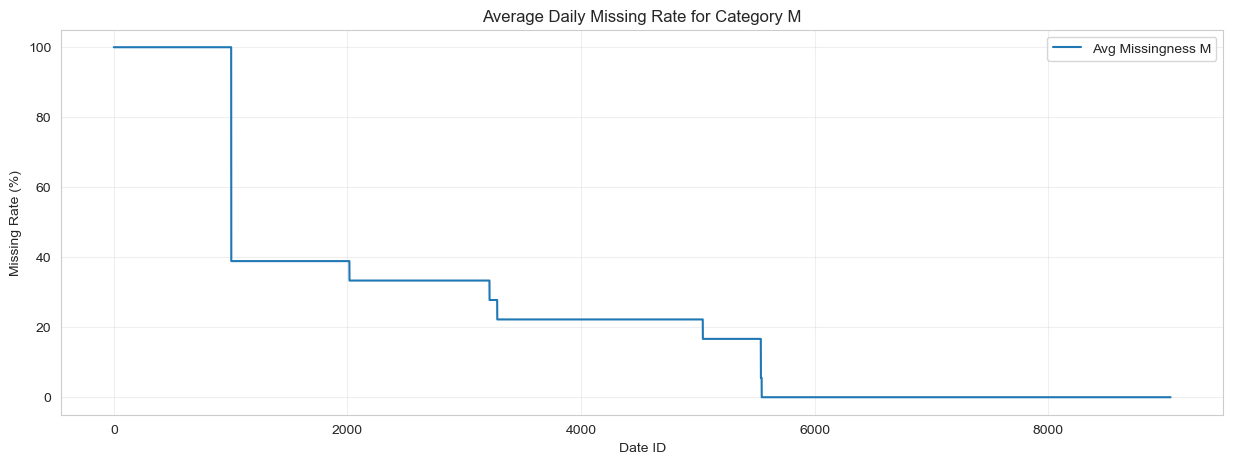

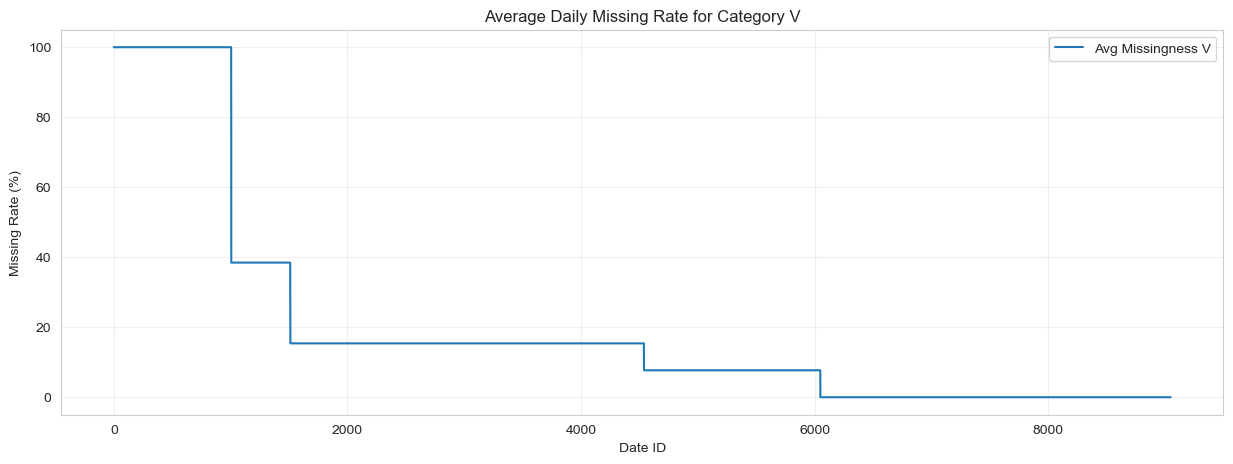

In [75]:
# Visualize Missingness for M and V features over time
for cat in ['M', 'V']:
    cat_cols = [col for col in train.columns if col.startswith(cat)]
    if cat_cols:
        # Calculate row-wise missing percentage for the category
        # using numeric date_id assuming it correlates with time
        # Try-except block to handle cases where date_id might not be unique in index or other issues
        try:
             cat_daily_missing = train.groupby('date_id')[cat_cols].apply(lambda x: x.isnull().mean().mean()).reset_index()
             cat_daily_missing.columns = ['date_id', 'missing_rate']
             cat_daily_missing['missing_rate'] = cat_daily_missing['missing_rate'] * 100
             
             plt.figure(figsize=(15, 5))
             plt.plot(cat_daily_missing['date_id'], cat_daily_missing['missing_rate'], label=f'Avg Missingness {cat}')
             plt.title(f'Average Daily Missing Rate for Category {cat}')
             plt.xlabel('Date ID')
             plt.ylabel('Missing Rate (%)')
             plt.legend()
             plt.grid(True, alpha=0.3)
             plt.show()
        except Exception as e:
            print(f"Error plotting missingness for {cat}: {e}")

# 6. SHAP Analysis — Per-Feature Contribution (XGBoost)

Quantify how **each explanatory variable** contributes to predicting `market_forward_excess_returns` (excess returns), using SHAP values.

- **Model**: XGBoost (handles NaN natively, so no imputation is required).
- **Data**: This section is for **interpretation only**. It re-loads the full `train.csv` (**without** the last-180-day split used earlier), fits a single model on all data, and computes SHAP.
- **Layout**:
  1. **1a** Top-20 global importance bar (main text) + **1b** all-94 bar (appendix) — which variables matter most.
  2. **2.** Beeswarm plots — importance, direction, and distribution at once (one per feature family, an assembled grid, and an overall Top 20).
  3. **3.** Family aggregation (D/E/I/M/P/S/V) — which signal group is most explanatory overall.
  4. **4.** Dependence plots — non-linearity / turning points for the Top 3 variables.


In [ ]:
# === SHAP analysis: SHAP value per explanatory variable (XGBoost) ===
# Interpretation only: re-load the full train.csv (NOT the last-180-day split used earlier)
import os
import shap
from xgboost import XGBRegressor

TARGET = 'market_forward_excess_returns'
NON_FEATURES = ['date_id', 'forward_returns', 'risk_free_rate', TARGET]

shap_data = (pd.read_csv('train.csv')
             .dropna(subset=[TARGET])          # rows with NaN target cannot be training samples
             .reset_index(drop=True))
shap_feature_cols = [c for c in shap_data.columns if c not in NON_FEATURES]
X_shap = shap_data[shap_feature_cols]
y_shap = shap_data[TARGET]
print(f"Samples: {len(X_shap)},  explanatory variables: {X_shap.shape[1]}")

SHAP_OUT = os.path.join('plots', 'shap')
os.makedirs(SHAP_OUT, exist_ok=True)

# XGBoost fit on all data (handles NaN natively, no imputation needed)
shap_model = XGBRegressor(
    n_estimators=600, learning_rate=0.03, max_depth=4,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42, n_jobs=-1,
)
shap_model.fit(X_shap, y_shap)

# TreeExplainer: exact and fast for tree models
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X_shap)               # Explanation object (values / data / feature_names)

# Global importance per variable = mean |SHAP|
mean_abs = np.abs(shap_values.values).mean(axis=0)
shap_imp = (pd.DataFrame({'feature': shap_feature_cols, 'mean_abs_shap': mean_abs})
            .sort_values('mean_abs_shap', ascending=False)
            .reset_index(drop=True))
shap_imp.to_csv(os.path.join(SHAP_OUT, 'shap_feature_importance.csv'), index=False)
print("\nTop 10 variables (mean |SHAP|):")
display(shap_imp.head(10))

In [ ]:
# 1a Main text — Top 20 global importance bar (mean |SHAP|)
#    Custom barh with scientific-notation labels (avoids shap's built-in bar rounding tiny values to "+0")
top20 = shap_imp.head(20).iloc[::-1]
plt.figure(figsize=(8, 8))
bars = plt.barh(top20['feature'], top20['mean_abs_shap'], color='#1f77b4')
plt.xlabel('mean |SHAP value|')
plt.title('1a. Global feature importance (mean |SHAP|) - Top 20')
for b, v in zip(bars, top20['mean_abs_shap']):
    plt.text(v, b.get_y() + b.get_height() / 2, f'  {v:.2e}', va='center', fontsize=8)
plt.margins(x=0.15)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT, 'bar_top20.png'), dpi=150, bbox_inches='tight')
plt.show()

# 1b Appendix — all 94 variables (custom barh to fit this many rows)
imp_asc = shap_imp.iloc[::-1]
plt.figure(figsize=(8, 18))
plt.barh(imp_asc['feature'], imp_asc['mean_abs_shap'], color='#1f77b4')
plt.xlabel('mean |SHAP value|')
plt.title(f'1b. Global feature importance - all {len(shap_feature_cols)} features')
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT, 'bar_all94.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 2. Beeswarm — one plot per family (all variables in the family) + overall Top 20
#    Each dot is a sample; color = feature value (high/low); x = that sample's SHAP value
families = {
    'D': 'D (dummy/binary)', 'E': 'E (economic)', 'I': 'I (interest/macro)',
    'M': 'M (market/momentum)', 'P': 'P (price/valuation)',
    'S': 'S (sentiment)', 'V': 'V (volatility)',
}

# Per family: subset the variables sharing the prefix, plot all of them
for prefix, label in families.items():
    cols = [c for c in shap_feature_cols if c.startswith(prefix)]
    idx = [shap_feature_cols.index(c) for c in cols]            # positions in the original columns
    shap.plots.beeswarm(shap_values[:, idx], max_display=len(cols), show=False)
    plt.title(f'2. Beeswarm — family {label}  ({len(cols)} vars)')
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUT, f'beeswarm_family_{prefix}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

# Finally: overall Top 20 (cross-family comparison)
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('2. Beeswarm — overall Top 20')
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT, 'beeswarm_top20.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 2. (Grid) Assemble the 7 family beeswarms into one overview figure (one slide)
#    Read the family PNGs saved by the previous cell and tile them
#    (shap.beeswarm builds its own figure each call, so tiling images is the robust way)
import matplotlib.image as mpimg

grid_order = ['M', 'P', 'E', 'S', 'V', 'I', 'D']        # ordered by family importance
fig, axes = plt.subplots(4, 2, figsize=(20, 32))
axes = axes.flatten()
for ax, prefix in zip(axes, grid_order):
    ax.imshow(mpimg.imread(os.path.join(SHAP_OUT, f'beeswarm_family_{prefix}.png')))
    ax.axis('off')
for ax in axes[len(grid_order):]:                        # turn off the leftover empty cell
    ax.axis('off')
fig.suptitle('SHAP beeswarm by feature family (D/E/I/M/P/S/V)', fontsize=20, y=0.997)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT, 'beeswarm_family_grid.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# 3. Feature-family importance (D/E/I/M/P/S/V) + 4. Dependence plots (Top 3)

# 3. Sum mean|SHAP| of variables within each prefix to see which signal group is most explanatory
shap_imp['family'] = shap_imp['feature'].str.extract(r'^([A-Za-z]+)')
fam = shap_imp.groupby('family')['mean_abs_shap'].sum().sort_values(ascending=False)
fam_names = {
    'D': 'D (dummy/binary)', 'E': 'E (economic)', 'I': 'I (interest/macro)',
    'M': 'M (market/momentum)', 'P': 'P (price/valuation)',
    'S': 'S (sentiment)', 'V': 'V (volatility)',
}
plt.figure(figsize=(8, 5))
plt.bar([fam_names.get(f, f) for f in fam.index], fam.values, color='#ff7f0e')
plt.ylabel('sum of mean |SHAP| within family')
plt.title('3. Feature-family importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUT, 'family_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

# 4. Dependence plots for the Top 3 variables: SHAP value vs feature value (non-linearity / turning points)
for rank, feat in enumerate(shap_imp['feature'].head(3), start=1):
    plt.figure()
    shap.plots.scatter(shap_values[:, feat], show=False)
    plt.title(f'4. SHAP dependence - {feat} (rank {rank})')
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUT, f'dependence_{rank}_{feat}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()